# Step 4 — Final Deployment Optimization and Backend Benchmarking
## YOLO26s / RT-DETR-R18 / BPD-YOLOn/L-FPN

This notebook is the final Step-4 pipeline for the aerial human detection project.

### Scope
- Uses the three final Step-3 checkpoints.
- Uses the **VisDrone2019-DET validation split (548 images)** for both accuracy and speed benchmarking.
- Maps native VisDrone categories **1 = pedestrian** and **2 = people** to a single `person` class.
- Keeps all other VisDrone object categories out of the person-only evaluation.
- Does **not** use the independent private Final Test.
- Does **not** run ByteTrack; tracking belongs to Step 5.
- Uses a fixed **1280 × 1280**, batch-size-1 deployment profile.

### Backends
For every model, the notebook attempts to preserve and evaluate:
1. Original PyTorch checkpoint.
2. ONNX FP32 export.
3. TensorRT FP16 engine.

### Metrics
The same validation images are used for:
- mAP50-95
- AP50
- AP75
- AP Tiny
- AP Small
- AP Medium
- AP Large
- Precision at the operating point
- Recall at the operating point
- Mean / P50 / P95 latency
- FPS
- Peak process VRAM
- Artifact size and SHA-256

### Important deployment note
TensorRT engines are hardware/runtime specific. Engines created here are named with the active GPU
(e.g. `L4`) and should be rebuilt on the final RTX 3070 system when that hardware becomes available.
The ONNX files are the portable deployment artifacts.

## 1. Mount Google Drive

This cell works in Google Colab. In a normal Jupyter environment it simply continues without mounting.

In [1]:
import importlib.util
from pathlib import Path

IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    print("Google Drive mounted.")
else:
    print("Google Colab was not detected.")
    print("For local Jupyter, change OUTPUT_ROOT in the configuration cell.")

Mounted at /content/drive
Google Drive mounted.


## 2. Install the controlled runtime dependencies

The project keeps the same Ultralytics version used by the recent inference notebooks.
TensorRT is installed through NVIDIA's Python package when it is not already available.

In [ ]:
import importlib
import subprocess
import sys

BASE_PACKAGES = [
    "ultralytics==8.4.116",
    "gdown>=5.2.0",
    "PyYAML>=6.0",
    "pandas>=2.0",
    "tqdm>=4.66",
    "pillow>=10.0",
    "requests>=2.31",
    "onnx>=1.17",
    "onnxruntime-gpu>=1.20",
    "pycocotools>=2.0.8",
    "faster-coco-eval>=1.6.7",
    "onnxslim>=0.1.65",
    "matplotlib>=3.8",
    "nvidia-ml-py>=12.560.30",
]

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade-strategy",
        "only-if-needed",
        *BASE_PACKAGES,
    ]
)

try:
    import tensorrt as trt
except Exception:
    import torch
    cuda_text = str(torch.version.cuda or "")
    package = "tensorrt-cu12" if cuda_text.startswith("12") else "tensorrt"
    print(f"TensorRT Python package was not found. Installing {package}...")
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--upgrade",
            package,
        ]
    )
    importlib.invalidate_caches()
    import tensorrt as trt

import cv2
import gdown
import matplotlib
import numpy as np
import onnx
import onnxruntime as ort
import pandas as pd
import requests
import torch
import torchvision
import ultralytics

print("Python       :", sys.version.split()[0])
print("PyTorch      :", torch.__version__)
print("Torchvision  :", torchvision.__version__)
print("CUDA         :", torch.version.cuda)
print("Ultralytics  :", ultralytics.__version__)
print("ONNX         :", onnx.__version__)
print("ONNX Runtime :", ort.__version__)
print("TensorRT     :", trt.__version__)
print("OpenCV       :", cv2.__version__)

if torch.cuda.is_available():
    print("GPU          :", torch.cuda.get_device_name(0))
else:
    raise RuntimeError(
        "CUDA GPU is required for the controlled Step-4 TensorRT benchmark."
    )

print("Runtime dependency setup: PASSED")

Python       : 3.12.13
PyTorch      : 2.13.0+cu130
Torchvision  : 0.28.0+cu130
CUDA         : 13.0
Ultralytics  : 8.4.116
ONNX         : 1.21.0
ONNX Runtime : 1.24.4
TensorRT     : 11.2.1.2
OpenCV       : 5.0.0
GPU          : NVIDIA L4
Runtime dependency setup: PASSED


## 3. User configuration

The three final model links are already filled in.

For the controlled project run:
- keep `IMAGE_SIZE = 1280`;
- keep `BATCH_SIZE = 1`;
- use an NVIDIA L4 when available;
- keep the private Final Test completely outside this notebook.

In [ ]:
from pathlib import Path

# ============================================================
# FINAL STEP-3 MODEL SOURCES
# ============================================================

YOLO26S_MODEL_SOURCE = (
    "https://drive.google.com/file/d/"
    "1Ds2wuTMp1voGOH-VbNhqFfM-xwhpvBcL/"
    "view?usp=drive_link"
)

RTDETR_MODEL_SOURCE = (
    "https://drive.google.com/file/d/"
    "1Ku_Sh9i-aCN2aLaDQH8tDfgrTzBFzZ3M/"
    "view?usp=drive_link"
)

BPD_MODEL_SOURCE = (
    "https://drive.google.com/file/d/"
    "1sV5nb8uU4E_b_7JDitpbYbxoM0x2ob2H/"
    "view?usp=drive_link"
)


# ============================================================
# OUTPUT ROOT
# ============================================================

OUTPUT_ROOT = Path(
    "/content/drive/MyDrive/aerial_human_detection/step4_final"
    if IN_COLAB
    else "./step4_final"
)


# ============================================================
# CONTROLLED DEPLOYMENT PROFILE
# ============================================================

IMAGE_SIZE = 1280
BATCH_SIZE = 1
DEVICE_ID = 0

# Low score floor for AP/mAP calculation.
# Do not use 0.50 here because AP requires the confidence ranking.
ACCURACY_CONF_FLOOR = 0.001

# Operating point used only for the reported single Precision/Recall pair.
OPERATING_CONF_THRESHOLD = 0.25
OPERATING_IOU_THRESHOLD = 0.50

# NMS settings for YOLO-family backends.
NMS_IOU_THRESHOLD = 0.70
MAX_DETECTIONS = 3000

# Benchmark settings.
WARMUP_RUNS = 10
BENCHMARK_USE_ALL_548_IMAGES = True
BENCHMARK_LIMIT = None

# Require L4 for the controlled official Step-4 run.
# Set False only for debugging on another NVIDIA GPU.
REQUIRE_L4 = True

# Export/evaluation switches.
RUN_PYTORCH = True
RUN_ONNX = True
RUN_TENSORRT_FP16 = True

# Resume-safe behavior.
RESUME_EXISTING_RESULTS = True
CONTINUE_ON_ERROR = True

# TensorRT build workspace.
TENSORRT_WORKSPACE_GB = 6

# Official pinned RT-DETR source used by the project.
RTDETR_REPO_URL = "https://github.com/lyuwenyu/RT-DETR.git"
RTDETR_REPO_COMMIT = "199fc382f53abbfb5c1804c97b0e8b204e3cb8d0"

# Known Step-2 VisDrone validation archive integrity record.
VISDRONE_VAL_EXPECTED_IMAGES = 548
VISDRONE_VAL_EXPECTED_BYTES = 81_638_851
VISDRONE_VAL_SHA256 = (
    "abeea063037e5d20398837deb11084e652402a34ddf4f207bdf541a6f2a35ef9"
)

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("Output root           :", OUTPUT_ROOT)
print("Image size            :", IMAGE_SIZE)
print("Batch size            :", BATCH_SIZE)
print("Accuracy score floor  :", ACCURACY_CONF_FLOOR)
print("Operating confidence  :", OPERATING_CONF_THRESHOLD)
print("Operating IoU         :", OPERATING_IOU_THRESHOLD)
print("Max detections        :", MAX_DETECTIONS)
print("Warm-up runs          :", WARMUP_RUNS)
print("Require L4            :", REQUIRE_L4)

Output root           : /content/drive/MyDrive/aerial_human_detection/step4_final
Image size            : 1280
Batch size            : 1
Accuracy score floor  : 0.001
Operating confidence  : 0.25
Operating IoU         : 0.5
Max detections        : 3000
Warm-up runs          : 10
Require L4            : True


## 4. Create the Step-4 delivery structure and record the environment

In [ ]:
import hashlib
import json
import os
import platform
import shutil
import subprocess
import time
from datetime import datetime

MODEL_DIRS = {
    "YOLO26s": OUTPUT_ROOT / "01_YOLO26s",
    "RT-DETR-R18": OUTPUT_ROOT / "02_RTDETR_R18",
    "BPD-YOLOn/L-FPN": OUTPUT_ROOT / "03_BPD_YOLOn_LFPN",
}

COMPARISON_DIR = OUTPUT_ROOT / "04_COMPARISON"
ENV_DIR = OUTPUT_ROOT / "05_ENVIRONMENT"
REPORT_ASSETS_DIR = OUTPUT_ROOT / "06_REPORT_ASSETS"
DATA_DIR = OUTPUT_ROOT / "00_DATA"

for root in [
    *MODEL_DIRS.values(),
    COMPARISON_DIR,
    ENV_DIR,
    REPORT_ASSETS_DIR,
    DATA_DIR,
]:
    root.mkdir(parents=True, exist_ok=True)

for root in MODEL_DIRS.values():
    for name in [
        "01_checkpoint",
        "02_onnx",
        "03_tensorrt_fp16",
        "04_benchmark",
    ]:
        (root / name).mkdir(parents=True, exist_ok=True)


def sha256_file(path: Path, block_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        while True:
            chunk = stream.read(block_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()


GPU_NAME = torch.cuda.get_device_name(DEVICE_ID)
GPU_TAG = "".join(
    ch if ch.isalnum() else "_"
    for ch in GPU_NAME
).strip("_")

if REQUIRE_L4 and "L4" not in GPU_NAME.upper():
    raise RuntimeError(
        f"The controlled Step-4 run requires NVIDIA L4, "
        f"but the active GPU is: {GPU_NAME}"
    )

environment = {
    "timestamp": datetime.now().isoformat(),
    "platform": platform.platform(),
    "python": sys.version,
    "pytorch": torch.__version__,
    "torchvision": torchvision.__version__,
    "cuda": torch.version.cuda,
    "gpu": GPU_NAME,
    "gpu_total_memory_gb": (
        torch.cuda.get_device_properties(DEVICE_ID).total_memory / (1024 ** 3)
    ),
    "ultralytics": ultralytics.__version__,
    "onnx": onnx.__version__,
    "onnxruntime": ort.__version__,
    "onnxruntime_providers": ort.get_available_providers(),
    "tensorrt": trt.__version__,
    "opencv": cv2.__version__,
    "rtdetr_repo": RTDETR_REPO_URL,
    "rtdetr_commit": RTDETR_REPO_COMMIT,
}

(ENV_DIR / "environment.json").write_text(
    json.dumps(environment, indent=2),
    encoding="utf-8",
)

with (ENV_DIR / "pip_freeze.txt").open("w", encoding="utf-8") as stream:
    subprocess.run(
        [sys.executable, "-m", "pip", "freeze"],
        stdout=stream,
        stderr=subprocess.STDOUT,
        text=True,
        check=False,
    )

with (ENV_DIR / "gpu_info.txt").open("w", encoding="utf-8") as stream:
    subprocess.run(
        ["nvidia-smi"],
        stdout=stream,
        stderr=subprocess.STDOUT,
        text=True,
        check=False,
    )

execution_config = {
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "accuracy_conf_floor": ACCURACY_CONF_FLOOR,
    "operating_conf_threshold": OPERATING_CONF_THRESHOLD,
    "operating_iou_threshold": OPERATING_IOU_THRESHOLD,
    "nms_iou_threshold": NMS_IOU_THRESHOLD,
    "max_detections": MAX_DETECTIONS,
    "warmup_runs": WARMUP_RUNS,
    "dataset": "VisDrone2019-DET validation",
    "target_class": "person",
    "native_person_categories": [1, 2],
    "private_final_test_used": False,
}

(ENV_DIR / "execution_config.json").write_text(
    json.dumps(execution_config, indent=2),
    encoding="utf-8",
)

print("GPU        :", GPU_NAME)
print("GPU tag    :", GPU_TAG)
print("Environment:", ENV_DIR)
print("Step-4 directory structure: READY")

GPU        : NVIDIA L4
GPU tag    : NVIDIA_L4
Environment: /content/drive/MyDrive/aerial_human_detection/step4_final/05_ENVIRONMENT
Step-4 directory structure: READY


## 5. Resolve and archive the three final checkpoints

Every checkpoint is cached locally for execution and copied into the Step-4 Google Drive delivery.

In [ ]:
import gdown

LOCAL_MODEL_CACHE = Path("/content/step4_model_cache" if IN_COLAB else "./step4_model_cache")
LOCAL_MODEL_CACHE.mkdir(parents=True, exist_ok=True)

MODEL_SOURCES = {
    "YOLO26s": YOLO26S_MODEL_SOURCE,
    "RT-DETR-R18": RTDETR_MODEL_SOURCE,
    "BPD-YOLOn/L-FPN": BPD_MODEL_SOURCE,
}

MODEL_FILENAMES = {
    "YOLO26s": "yolo26s_best.pt",
    "RT-DETR-R18": "rtdetr_r18_best.pth",
    "BPD-YOLOn/L-FPN": "bpd_yolon_lfpn_best.pt",
}


def is_http_url(value) -> bool:
    return isinstance(value, str) and value.strip().lower().startswith(
        ("http://", "https://")
    )


def resolve_model_source(model_name: str, source: str) -> Path:
    target = LOCAL_MODEL_CACHE / MODEL_FILENAMES[model_name]

    if target.exists() and target.stat().st_size > 1_000_000:
        print(f"{model_name}: using cached checkpoint: {target}")
        return target

    source_text = str(source).strip()

    if is_http_url(source_text):
        print(f"{model_name}: downloading shared Google Drive checkpoint...")
        result = gdown.download(
            url=source_text,
            output=str(target),
            quiet=False,
            fuzzy=True,
        )
        if result is None:
            raise RuntimeError(f"gdown failed for {model_name}: {source_text}")
    else:
        source_path = Path(source_text)
        if not source_path.exists():
            raise FileNotFoundError(source_path)
        shutil.copy2(source_path, target)

    if not target.exists() or target.stat().st_size <= 1_000_000:
        raise RuntimeError(
            f"Resolved checkpoint is missing or too small: {target}"
        )

    return target


MODEL_PATHS = {}
MODEL_ARTIFACTS = {}

for model_name, source in MODEL_SOURCES.items():
    print("\n" + "=" * 88)
    print("RESOLVING:", model_name)
    print("=" * 88)

    local_path = resolve_model_source(model_name, source)
    checkpoint_dir = MODEL_DIRS[model_name] / "01_checkpoint"
    archived_path = checkpoint_dir / MODEL_FILENAMES[model_name]

    if not archived_path.exists() or archived_path.stat().st_size != local_path.stat().st_size:
        shutil.copy2(local_path, archived_path)

    checkpoint_hash = sha256_file(archived_path)

    (checkpoint_dir / "sha256.txt").write_text(
        checkpoint_hash + "\n",
        encoding="utf-8",
    )

    MODEL_PATHS[model_name] = local_path
    MODEL_ARTIFACTS[model_name] = {
        "checkpoint": archived_path,
        "checkpoint_sha256": checkpoint_hash,
    }

    print("Local checkpoint :", local_path)
    print("Drive checkpoint :", archived_path)
    print("Size MiB         :", f"{archived_path.stat().st_size / 1024 / 1024:.2f}")
    print("SHA-256          :", checkpoint_hash)

print("\nAll three final checkpoints: READY")


RESOLVING: YOLO26s
YOLO26s: using cached checkpoint: /content/step4_model_cache/yolo26s_best.pt
Local checkpoint : /content/step4_model_cache/yolo26s_best.pt
Drive checkpoint : /content/drive/MyDrive/aerial_human_detection/step4_final/01_YOLO26s/01_checkpoint/yolo26s_best.pt
Size MiB         : 19.43
SHA-256          : d75f4e588de8c99240f8c6f4b594e42fc7bb14bd40cab7835714327f17c6765e

RESOLVING: RT-DETR-R18
RT-DETR-R18: using cached checkpoint: /content/step4_model_cache/rtdetr_r18_best.pth
Local checkpoint : /content/step4_model_cache/rtdetr_r18_best.pth
Drive checkpoint : /content/drive/MyDrive/aerial_human_detection/step4_final/02_RTDETR_R18/01_checkpoint/rtdetr_r18_best.pth
Size MiB         : 307.19
SHA-256          : de2251cf115fe27495622f5761d54acb0414a421b4f47e732a2b3b0e14406f3f

RESOLVING: BPD-YOLOn/L-FPN
BPD-YOLOn/L-FPN: using cached checkpoint: /content/step4_model_cache/bpd_yolon_lfpn_best.pt
Local checkpoint : /content/step4_model_cache/bpd_yolon_lfpn_best.pt
Drive checkpoin

## 6. Prepare the official VisDrone2019-DET validation split

The validation archive is reused from the Step-2 Drive folder when available.
Otherwise it is downloaded from the Ultralytics asset mirror used by the project.
The known Step-2 SHA-256 is checked.

In [ ]:
import zipfile
from tqdm.auto import tqdm
from ultralytics.utils import ASSETS_URL

VAL_ARCHIVE_NAME = "VisDrone2019-DET-val.zip"
VAL_ARCHIVE = DATA_DIR / VAL_ARCHIVE_NAME

STEP2_ARCHIVE_CANDIDATES = [
    Path(
        "/content/drive/MyDrive/AerialHumanDetection/"
        "Step2_VisDrone_Final/01_source_archives/VisDrone2019-DET-val.zip"
    ),
    Path(
        "/content/drive/MyDrive/aerial_human_detection/"
        "Step2_VisDrone_Final/01_source_archives/VisDrone2019-DET-val.zip"
    ),
]


def valid_visdrone_archive(path: Path) -> bool:
    if not path.exists():
        return False
    if path.stat().st_size != VISDRONE_VAL_EXPECTED_BYTES:
        return False
    return sha256_file(path) == VISDRONE_VAL_SHA256


if not valid_visdrone_archive(VAL_ARCHIVE):
    reused = False

    for candidate in STEP2_ARCHIVE_CANDIDATES:
        if valid_visdrone_archive(candidate):
            print("Reusing Step-2 validated archive:", candidate)
            shutil.copy2(candidate, VAL_ARCHIVE)
            reused = True
            break

    if not reused:
        url = f"{ASSETS_URL}/{VAL_ARCHIVE_NAME}"
        temp_path = VAL_ARCHIVE.with_suffix(".zip.part")

        if temp_path.exists():
            temp_path.unlink()

        print("Downloading:", url)

        with requests.get(
            url,
            stream=True,
            allow_redirects=True,
            timeout=(30, 180),
            headers={"User-Agent": "Mozilla/5.0"},
        ) as response:
            response.raise_for_status()
            total = int(response.headers.get("content-length", 0))

            with temp_path.open("wb") as stream, tqdm(
                total=total,
                unit="B",
                unit_scale=True,
                unit_divisor=1024,
                desc=VAL_ARCHIVE_NAME,
            ) as bar:
                for chunk in response.iter_content(chunk_size=1024 * 1024):
                    if chunk:
                        stream.write(chunk)
                        bar.update(len(chunk))

        temp_path.replace(VAL_ARCHIVE)

if not valid_visdrone_archive(VAL_ARCHIVE):
    actual_size = VAL_ARCHIVE.stat().st_size if VAL_ARCHIVE.exists() else 0
    actual_hash = sha256_file(VAL_ARCHIVE) if VAL_ARCHIVE.exists() else None
    raise RuntimeError(
        "VisDrone validation archive integrity check failed.\n"
        f"Expected bytes : {VISDRONE_VAL_EXPECTED_BYTES}\n"
        f"Actual bytes   : {actual_size}\n"
        f"Expected SHA256: {VISDRONE_VAL_SHA256}\n"
        f"Actual SHA256  : {actual_hash}"
    )

LOCAL_DATA_ROOT = Path("/content/step4_visdrone" if IN_COLAB else "./step4_visdrone")
LOCAL_DATA_ROOT.mkdir(parents=True, exist_ok=True)
EXTRACT_MARKER = LOCAL_DATA_ROOT / ".val_extracted_ok"

if not EXTRACT_MARKER.exists():
    if any(LOCAL_DATA_ROOT.iterdir()):
        for item in LOCAL_DATA_ROOT.iterdir():
            if item != EXTRACT_MARKER:
                if item.is_dir():
                    shutil.rmtree(item)
                else:
                    item.unlink()

    print("Extracting VisDrone validation archive...")
    with zipfile.ZipFile(VAL_ARCHIVE, "r") as archive:
        archive.extractall(LOCAL_DATA_ROOT)

    EXTRACT_MARKER.write_text("ok\n", encoding="utf-8")


IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}


def locate_visdrone_val(root: Path):
    candidates = []

    for images_dir in root.rglob("images"):
        ann_dir = images_dir.parent / "annotations"
        if not images_dir.is_dir() or not ann_dir.is_dir():
            continue

        count = sum(
            1
            for p in images_dir.iterdir()
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
        )

        candidates.append((abs(count - VISDRONE_VAL_EXPECTED_IMAGES), -count, images_dir, ann_dir))

    if not candidates:
        raise FileNotFoundError(
            f"Could not locate VisDrone images/annotations under: {root}"
        )

    candidates.sort(key=lambda x: (x[0], x[1]))
    _, _, images_dir, ann_dir = candidates[0]

    count = sum(
        1
        for p in images_dir.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    )

    if count != VISDRONE_VAL_EXPECTED_IMAGES:
        raise RuntimeError(
            f"Expected {VISDRONE_VAL_EXPECTED_IMAGES} validation images, found {count}."
        )

    return images_dir, ann_dir


VAL_IMAGES_DIR, VAL_ANN_DIR = locate_visdrone_val(LOCAL_DATA_ROOT)
VAL_IMAGE_FILES = sorted(
    p for p in VAL_IMAGES_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
)

print("Validation images :", VAL_IMAGES_DIR)
print("Annotations       :", VAL_ANN_DIR)
print("Image count       :", len(VAL_IMAGE_FILES))
print("Archive SHA-256   :", sha256_file(VAL_ARCHIVE))
print("VisDrone validation setup: PASSED")

Validation images : /content/step4_visdrone/VisDrone2019-DET-val/images
Annotations       : /content/step4_visdrone/VisDrone2019-DET-val/annotations
Image count       : 548
Archive SHA-256   : abeea063037e5d20398837deb11084e652402a34ddf4f207bdf541a6f2a35ef9
VisDrone validation setup: PASSED


## 7. Build the canonical person-only COCO ground truth

Rules:
- native category 1 (`pedestrian`) → `person`
- native category 2 (`people`) → `person`
- rows with `score = 0` are ignored
- all other native categories are ignored
- background images are retained

In [ ]:
from PIL import Image

COCO_GT_JSON = DATA_DIR / "visdrone_val_person_only_coco.json"
IMAGE_INDEX_JSON = DATA_DIR / "visdrone_val_image_index.json"


def parse_visdrone_annotation_file(path: Path):
    rows = []

    if not path.exists():
        return rows

    for raw_line in path.read_text(encoding="utf-8-sig", errors="ignore").splitlines():
        line = raw_line.strip()
        if not line:
            continue

        parts = [x.strip() for x in line.split(",")]
        if len(parts) < 6:
            continue

        try:
            x = float(parts[0])
            y = float(parts[1])
            w = float(parts[2])
            h = float(parts[3])
            score = int(float(parts[4]))
            category = int(float(parts[5]))
        except ValueError:
            continue

        if score == 0:
            continue

        if category not in {1, 2}:
            continue

        rows.append((x, y, w, h))

    return rows


images = []
annotations = []
image_index = {}
annotation_id = 1

for image_id, image_path in enumerate(
    tqdm(VAL_IMAGE_FILES, desc="Building person-only COCO ground truth"),
    start=1,
):
    with Image.open(image_path) as image:
        width, height = image.size

    images.append(
        {
            "id": image_id,
            "file_name": image_path.name,
            "width": width,
            "height": height,
        }
    )

    image_index[image_path.name] = image_id

    ann_path = VAL_ANN_DIR / f"{image_path.stem}.txt"

    for x, y, w, h in parse_visdrone_annotation_file(ann_path):
        x1 = max(0.0, min(float(width), x))
        y1 = max(0.0, min(float(height), y))
        x2 = max(0.0, min(float(width), x + w))
        y2 = max(0.0, min(float(height), y + h))

        clipped_w = x2 - x1
        clipped_h = y2 - y1

        if clipped_w <= 0 or clipped_h <= 0:
            continue

        annotations.append(
            {
                "id": annotation_id,
                "image_id": image_id,
                "category_id": 1,
                "bbox": [x1, y1, clipped_w, clipped_h],
                "area": clipped_w * clipped_h,
                "iscrowd": 0,
            }
        )

        annotation_id += 1

coco_gt = {
    "info": {
        "description": "VisDrone2019-DET validation person-only mapping",
        "mapping": "native categories 1 pedestrian + 2 people -> person",
    },
    "licenses": [],
    "images": images,
    "annotations": annotations,
    "categories": [
        {
            "id": 1,
            "name": "person",
            "supercategory": "person",
        }
    ],
}

COCO_GT_JSON.write_text(
    json.dumps(coco_gt),
    encoding="utf-8",
)

IMAGE_INDEX_JSON.write_text(
    json.dumps(image_index, indent=2),
    encoding="utf-8",
)

print("COCO ground truth :", COCO_GT_JSON)
print("Images            :", len(images))
print("Person boxes      :", len(annotations))
print("Background images :", len(images) - len({a["image_id"] for a in annotations}))
print("Person-only COCO ground truth: READY")

Building person-only COCO ground truth:   0%|          | 0/548 [00:00<?, ?it/s]

COCO ground truth : /content/drive/MyDrive/aerial_human_detection/step4_final/00_DATA/visdrone_val_person_only_coco.json
Images            : 548
Person boxes      : 13969
Background images : 17
Person-only COCO ground truth: READY


## 8. BPD-YOLOn/L-FPN compatibility

This is the compatibility layer used by the current project checkpoint so that the serialized custom `DySample`
layer can be loaded and exported by Ultralytics.

In [ ]:
import sys
import torch.nn as nn
import torch.nn.functional as F


class DySample(nn.Module):
    def __init__(self, channels=None, scale=2, max_offset=0.25):
        super().__init__()
        self.channels = int(channels) if channels is not None else None
        self.scale = int(scale)
        self.max_offset = float(max_offset)

        if self.channels is None:
            self.offset = nn.LazyConv2d(2, kernel_size=1, stride=1, padding=0)
            self._zero_initialized = False
        else:
            self.offset = nn.Conv2d(
                self.channels,
                2,
                kernel_size=1,
                stride=1,
                padding=0,
            )
            with torch.no_grad():
                nn.init.zeros_(self.offset.weight)
                if self.offset.bias is not None:
                    nn.init.zeros_(self.offset.bias)

    def _materialize_legacy_lazy_offset(self, x):
        if (
            isinstance(self.offset, nn.LazyConv2d)
            and not getattr(self, "_zero_initialized", False)
        ):
            _ = self.offset(x)
            with torch.no_grad():
                nn.init.zeros_(self.offset.weight)
                if self.offset.bias is not None:
                    nn.init.zeros_(self.offset.bias)
            self._zero_initialized = True

    def forward(self, x):
        channels = getattr(self, "channels", None)

        if channels is not None and x.shape[1] != int(channels):
            raise RuntimeError(
                f"DySample expected {int(channels)} channels "
                f"but received {x.shape[1]}."
            )

        self._materialize_legacy_lazy_offset(x)

        b, _, h, w = x.shape
        scale = int(getattr(self, "scale", 2))
        max_offset = float(getattr(self, "max_offset", 0.25))
        oh = h * scale
        ow = w * scale

        raw = self.offset(x)
        raw = F.interpolate(
            raw,
            size=(oh, ow),
            mode="bilinear",
            align_corners=False,
        )
        raw = torch.tanh(raw) * max_offset

        ys = (
            ((torch.arange(oh, device=x.device, dtype=x.dtype) + 0.5) / oh)
            * 2.0
            - 1.0
        )
        xs = (
            ((torch.arange(ow, device=x.device, dtype=x.dtype) + 0.5) / ow)
            * 2.0
            - 1.0
        )

        yy, xx = torch.meshgrid(ys, xs, indexing="ij")
        base = (
            torch.stack((xx, yy), dim=-1)
            .unsqueeze(0)
            .expand(b, -1, -1, -1)
        )

        dx = raw[:, 0] * (2.0 / max(w, 1))
        dy = raw[:, 1] * (2.0 / max(h, 1))
        grid = base + torch.stack((dx, dy), dim=-1)

        return F.grid_sample(
            x,
            grid,
            mode="bilinear",
            padding_mode="border",
            align_corners=False,
        )


def register_bpd_compatibility():
    import ultralytics.nn.tasks as ultralytics_tasks

    setattr(sys.modules["__main__"], "DySample", DySample)
    setattr(ultralytics_tasks, "DySample", DySample)

    try:
        import ultralytics.nn.modules as ultralytics_modules
        setattr(ultralytics_modules, "DySample", DySample)
    except Exception:
        pass

    try:
        torch.serialization.add_safe_globals([DySample])
    except Exception:
        pass


register_bpd_compatibility()
print("BPD DySample compatibility: REGISTERED")

BPD DySample compatibility: REGISTERED


## 9. Prepare the pinned official RT-DETR source and the single-class export configuration

In [ ]:
RTDETR_LOCAL_ROOT = Path("/content/step4_rtdetr" if IN_COLAB else "./step4_rtdetr")
RTDETR_REPO_ROOT = RTDETR_LOCAL_ROOT / "RT-DETR"
RTDETR_ROOT = RTDETR_REPO_ROOT / "rtdetrv2_pytorch"

RTDETR_LOCAL_ROOT.mkdir(parents=True, exist_ok=True)

if not RTDETR_REPO_ROOT.exists():
    subprocess.check_call(
        [
            "git",
            "clone",
            "--filter=blob:none",
            RTDETR_REPO_URL,
            str(RTDETR_REPO_ROOT),
        ]
    )

subprocess.check_call(
    [
        "git",
        "-C",
        str(RTDETR_REPO_ROOT),
        "fetch",
        "--all",
        "--tags",
        "--prune",
    ]
)

subprocess.check_call(
    [
        "git",
        "-C",
        str(RTDETR_REPO_ROOT),
        "checkout",
        "--force",
        RTDETR_REPO_COMMIT,
    ]
)

if not RTDETR_ROOT.exists():
    raise FileNotFoundError(RTDETR_ROOT)

if str(RTDETR_ROOT) not in sys.path:
    sys.path.insert(0, str(RTDETR_ROOT))

RTDETR_CONFIG_DIR = RTDETR_ROOT / "configs" / "custom"
RTDETR_CONFIG_DIR.mkdir(parents=True, exist_ok=True)
RTDETR_EXPORT_CONFIG = RTDETR_CONFIG_DIR / "rtdetr_r18_visdrone_person_step4.yml"

rtdetr_config_text = f"""
__include__:
  - ../rtdetr/rtdetr_r18vd_6x_coco.yml

num_classes: 1
remap_mscoco_category: False

eval_spatial_size: [{IMAGE_SIZE}, {IMAGE_SIZE}]

PResNet:
  pretrained: False
"""

RTDETR_EXPORT_CONFIG.write_text(
    rtdetr_config_text.strip() + "\n",
    encoding="utf-8",
)

written_config = RTDETR_EXPORT_CONFIG.read_text(encoding="utf-8")

if "\\n" in written_config:
    raise RuntimeError(
        "A literal backslash-n was found in the RT-DETR YAML."
    )

print("RT-DETR root   :", RTDETR_ROOT)
print("Pinned commit  :", RTDETR_REPO_COMMIT)
print("Export config  :", RTDETR_EXPORT_CONFIG)
print(written_config)
print("RT-DETR source/configuration: READY")

RT-DETR root   : /content/step4_rtdetr/RT-DETR/rtdetrv2_pytorch
Pinned commit  : 199fc382f53abbfb5c1804c97b0e8b204e3cb8d0
Export config  : /content/step4_rtdetr/RT-DETR/rtdetrv2_pytorch/configs/custom/rtdetr_r18_visdrone_person_step4.yml
__include__:
  - ../rtdetr/rtdetr_r18vd_6x_coco.yml

num_classes: 1
remap_mscoco_category: False

eval_spatial_size: [1280, 1280]

PResNet:
  pretrained: False

RT-DETR source/configuration: READY


## 10. Common prediction structures, metrics and VRAM monitor

In [ ]:
import contextlib
import gc
import threading
import traceback
from dataclasses import dataclass, asdict
from collections import defaultdict

from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
from pynvml import (
    nvmlInit,
    nvmlDeviceGetHandleByIndex,
    nvmlDeviceGetComputeRunningProcesses,
    nvmlShutdown,
)


@dataclass
class DetectionBatch:
    boxes: np.ndarray
    scores: np.ndarray
    classes: np.ndarray

    @classmethod
    def empty(cls):
        return cls(
            boxes=np.zeros((0, 4), dtype=np.float32),
            scores=np.zeros((0,), dtype=np.float32),
            classes=np.zeros((0,), dtype=np.float32),
        )

    def __len__(self):
        return len(self.boxes)


@dataclass
class TimingRecord:
    preprocess_ms: float
    inference_ms: float
    postprocess_ms: float
    total_ms: float


class ProcessVRAMMonitor:
    def __init__(self, device_index=0, interval=0.05):
        self.device_index = int(device_index)
        self.interval = float(interval)
        self.peak_mb = 0.0
        self._stop = threading.Event()
        self._thread = None

    def _read_mb(self):
        try:
            handle = nvmlDeviceGetHandleByIndex(self.device_index)
            processes = nvmlDeviceGetComputeRunningProcesses(handle)
            pid = os.getpid()

            for proc in processes:
                if int(proc.pid) == pid:
                    used = getattr(proc, "usedGpuMemory", 0) or 0
                    return float(used) / (1024 ** 2)
        except Exception:
            return 0.0

        return 0.0

    def _loop(self):
        while not self._stop.is_set():
            self.peak_mb = max(self.peak_mb, self._read_mb())
            self._stop.wait(self.interval)

    def __enter__(self):
        try:
            nvmlInit()
            self.peak_mb = self._read_mb()
            self._thread = threading.Thread(target=self._loop, daemon=True)
            self._thread.start()
        except Exception:
            self._thread = None
        return self

    def __exit__(self, exc_type, exc, tb):
        self._stop.set()
        if self._thread is not None:
            self._thread.join(timeout=1.0)
        try:
            self.peak_mb = max(self.peak_mb, self._read_mb())
            nvmlShutdown()
        except Exception:
            pass


def xyxy_to_xywh(boxes: np.ndarray) -> np.ndarray:
    if len(boxes) == 0:
        return np.zeros((0, 4), dtype=np.float32)

    out = boxes.astype(np.float32).copy()
    out[:, 2] = out[:, 2] - out[:, 0]
    out[:, 3] = out[:, 3] - out[:, 1]
    return out


def box_iou_matrix(boxes_a: np.ndarray, boxes_b: np.ndarray) -> np.ndarray:
    if len(boxes_a) == 0 or len(boxes_b) == 0:
        return np.zeros((len(boxes_a), len(boxes_b)), dtype=np.float32)

    a = boxes_a[:, None, :]
    b = boxes_b[None, :, :]

    inter_x1 = np.maximum(a[..., 0], b[..., 0])
    inter_y1 = np.maximum(a[..., 1], b[..., 1])
    inter_x2 = np.minimum(a[..., 2], b[..., 2])
    inter_y2 = np.minimum(a[..., 3], b[..., 3])

    inter_w = np.maximum(0.0, inter_x2 - inter_x1)
    inter_h = np.maximum(0.0, inter_y2 - inter_y1)
    intersection = inter_w * inter_h

    area_a = np.maximum(0.0, a[..., 2] - a[..., 0]) * np.maximum(
        0.0, a[..., 3] - a[..., 1]
    )
    area_b = np.maximum(0.0, b[..., 2] - b[..., 0]) * np.maximum(
        0.0, b[..., 3] - b[..., 1]
    )

    union = area_a + area_b - intersection
    return intersection / np.maximum(union, 1e-12)


def mean_valid(values):
    values = np.asarray(values)
    valid = values[values > -1]
    return float(valid.mean()) if valid.size else float("nan")


def evaluate_coco_predictions(prediction_json: Path):
    coco_gt = COCO(str(COCO_GT_JSON))

    predictions = json.loads(prediction_json.read_text(encoding="utf-8"))

    if predictions:
        coco_dt = coco_gt.loadRes(predictions)
    else:
        empty_path = prediction_json.with_name("empty_predictions.json")
        empty_path.write_text("[]", encoding="utf-8")
        coco_dt = coco_gt.loadRes(str(empty_path))

    evaluator = COCOeval(coco_gt, coco_dt, iouType="bbox")
    evaluator.params.maxDets = [1, 100, MAX_DETECTIONS]

    # Project size buckets based on equivalent square side.
    # Tiny   : sqrt(area) < 16
    # Small  : 16 <= sqrt(area) < 32
    # Medium : 32 <= sqrt(area) < 64
    # Large  : sqrt(area) >= 64
    evaluator.params.areaRng = [
        [0 ** 2, 1e10],
        [0 ** 2, 16 ** 2],
        [16 ** 2, 32 ** 2],
        [32 ** 2, 64 ** 2],
        [64 ** 2, 1e10],
    ]
    evaluator.params.areaRngLbl = [
        "all",
        "tiny",
        "small",
        "medium",
        "large",
    ]

    evaluator.evaluate()
    evaluator.accumulate()

    precision = evaluator.eval["precision"]
    recall = evaluator.eval["recall"]

    max_det_index = 2
    area_indices = {
        "all": 0,
        "tiny": 1,
        "small": 2,
        "medium": 3,
        "large": 4,
    }

    ious = evaluator.params.iouThrs
    iou50_index = int(np.argmin(np.abs(ious - 0.50)))
    iou75_index = int(np.argmin(np.abs(ious - 0.75)))

    metrics = {
        "map50_95": mean_valid(
            precision[:, :, :, area_indices["all"], max_det_index]
        ),
        "ap50": mean_valid(
            precision[iou50_index, :, :, area_indices["all"], max_det_index]
        ),
        "ap75": mean_valid(
            precision[iou75_index, :, :, area_indices["all"], max_det_index]
        ),
        "ap_tiny": mean_valid(
            precision[:, :, :, area_indices["tiny"], max_det_index]
        ),
        "ap_small": mean_valid(
            precision[:, :, :, area_indices["small"], max_det_index]
        ),
        "ap_medium": mean_valid(
            precision[:, :, :, area_indices["medium"], max_det_index]
        ),
        "ap_large": mean_valid(
            precision[:, :, :, area_indices["large"], max_det_index]
        ),
        "ar100": mean_valid(
            recall[:, :, area_indices["all"], 1]
        ),
        "ar_max": mean_valid(
            recall[:, :, area_indices["all"], max_det_index]
        ),
    }

    return metrics


GT_BY_IMAGE = defaultdict(list)

for ann in coco_gt["annotations"]:
    x, y, w, h = ann["bbox"]
    GT_BY_IMAGE[int(ann["image_id"])].append(
        [x, y, x + w, y + h]
    )

for image_id in list(GT_BY_IMAGE):
    GT_BY_IMAGE[image_id] = np.asarray(
        GT_BY_IMAGE[image_id],
        dtype=np.float32,
    )


def operating_point_precision_recall(predictions):
    pred_by_image = defaultdict(list)

    for pred in predictions:
        if float(pred["score"]) < OPERATING_CONF_THRESHOLD:
            continue

        x, y, w, h = pred["bbox"]
        pred_by_image[int(pred["image_id"])].append(
            [
                float(pred["score"]),
                x,
                y,
                x + w,
                y + h,
            ]
        )

    tp = 0
    fp = 0
    total_gt = sum(len(v) for v in GT_BY_IMAGE.values())

    all_image_ids = [
        int(item["id"])
        for item in coco_gt["images"]
    ]

    for image_id in all_image_ids:
        gt_boxes = GT_BY_IMAGE.get(
            image_id,
            np.zeros((0, 4), dtype=np.float32),
        )

        preds = pred_by_image.get(image_id, [])
        preds = sorted(preds, key=lambda row: row[0], reverse=True)

        matched = np.zeros((len(gt_boxes),), dtype=bool)

        for row in preds:
            box = np.asarray([row[1:5]], dtype=np.float32)

            if len(gt_boxes) == 0:
                fp += 1
                continue

            ious = box_iou_matrix(box, gt_boxes)[0]
            ious[matched] = -1.0

            best_index = int(np.argmax(ious))
            best_iou = float(ious[best_index])

            if best_iou >= OPERATING_IOU_THRESHOLD:
                tp += 1
                matched[best_index] = True
            else:
                fp += 1

    fn = total_gt - tp

    precision_value = tp / max(tp + fp, 1)
    recall_value = tp / max(tp + fn, 1)

    return {
        "precision_operating": precision_value,
        "recall_operating": recall_value,
        "tp_operating": int(tp),
        "fp_operating": int(fp),
        "fn_operating": int(fn),
    }


def summarize_timings(timing_df: pd.DataFrame):
    total = timing_df["total_ms"].to_numpy(dtype=float)
    preprocess = timing_df["preprocess_ms"].to_numpy(dtype=float)
    inference = timing_df["inference_ms"].to_numpy(dtype=float)
    postprocess = timing_df["postprocess_ms"].to_numpy(dtype=float)

    mean_total = float(np.mean(total))

    return {
        "mean_preprocess_ms": float(np.mean(preprocess)),
        "mean_inference_ms": float(np.mean(inference)),
        "mean_postprocess_ms": float(np.mean(postprocess)),
        "mean_latency_ms": mean_total,
        "p50_latency_ms": float(np.percentile(total, 50)),
        "p95_latency_ms": float(np.percentile(total, 95)),
        "fps": float(1000.0 / mean_total) if mean_total > 0 else float("nan"),
    }


print("Common metric and monitoring utilities: READY")

Common metric and monitoring utilities: READY


## 11. Export helpers

YOLO26s and BPD-YOLOn/L-FPN use the official Ultralytics export path.
RT-DETR-R18 uses the official repository's `tools/export_onnx.py`.
TensorRT FP16 for RT-DETR is built from its ONNX graph using the TensorRT Python API.

In [ ]:
from ultralytics import YOLO


def set_person_name_if_possible(model):
    try:
        if hasattr(model, "model") and hasattr(model.model, "names"):
            model.model.names = {0: "person"}
    except Exception:
        pass


def copy_export_artifact(source_path: Path, destination_path: Path):
    source_path = Path(source_path)
    destination_path.parent.mkdir(parents=True, exist_ok=True)

    if source_path.resolve() != destination_path.resolve():
        shutil.copy2(source_path, destination_path)

    if not destination_path.exists() or destination_path.stat().st_size == 0:
        raise RuntimeError(
            f"Export artifact was not created correctly: {destination_path}"
        )

    return destination_path


def export_ultralytics_onnx(model_name: str, checkpoint_path: Path) -> Path:
    out_dir = MODEL_DIRS[model_name] / "02_onnx"
    output_path = out_dir / (
        "yolo26s_1280.onnx"
        if model_name == "YOLO26s"
        else "bpd_yolon_lfpn_1280.onnx"
    )

    if RESUME_EXISTING_RESULTS and output_path.exists() and output_path.stat().st_size > 1_000_000:
        onnx.checker.check_model(onnx.load(str(output_path)))
        print(model_name, "ONNX already exists:", output_path)
        return output_path

    if model_name == "BPD-YOLOn/L-FPN":
        register_bpd_compatibility()

    model = YOLO(str(checkpoint_path))
    set_person_name_if_possible(model)

    # YOLO26 is end-to-end by default, so Ultralytics may automatically
    # disable exported NMS for that architecture. BPD/YOLOv8 uses nms=True.
    exported = model.export(
        format="onnx",
        imgsz=IMAGE_SIZE,
        batch=BATCH_SIZE,
        dynamic=False,
        simplify=True,
        opset=17,
        nms=True,
        conf=ACCURACY_CONF_FLOOR,
        iou=NMS_IOU_THRESHOLD,
        max_det=MAX_DETECTIONS,
        device=DEVICE_ID,
    )

    output_path = copy_export_artifact(
        Path(exported),
        output_path,
    )

    model_onnx = onnx.load(str(output_path))
    onnx.checker.check_model(model_onnx)

    del model
    gc.collect()
    torch.cuda.empty_cache()

    return output_path


def export_ultralytics_engine(
    model_name: str,
    checkpoint_path: Path,
) -> Path:
    out_dir = MODEL_DIRS[model_name] / "03_tensorrt_fp16"

    base_name = (
        "yolo26s"
        if model_name == "YOLO26s"
        else "bpd_yolon_lfpn"
    )

    output_path = out_dir / f"{base_name}_1280_{GPU_TAG}_fp16.engine"

    if RESUME_EXISTING_RESULTS and output_path.exists() and output_path.stat().st_size > 1_000_000:
        print(model_name, "TensorRT engine already exists:", output_path)
        return output_path

    if model_name == "BPD-YOLOn/L-FPN":
        register_bpd_compatibility()

    model = YOLO(str(checkpoint_path))
    set_person_name_if_possible(model)

    common_args = dict(
        format="engine",
        imgsz=IMAGE_SIZE,
        batch=BATCH_SIZE,
        dynamic=False,
        simplify=True,
        workspace=TENSORRT_WORKSPACE_GB,
        nms=True,
        conf=ACCURACY_CONF_FLOOR,
        iou=NMS_IOU_THRESHOLD,
        max_det=MAX_DETECTIONS,
        device=DEVICE_ID,
    )

    try:
        exported = model.export(
            quantize=16,
            **common_args,
        )
    except Exception as first_error:
        print(
            "TensorRT export with quantize=16 failed. "
            "Retrying with the legacy half=True argument."
        )
        print("First error:", first_error)

        exported = model.export(
            half=True,
            **common_args,
        )

    output_path = copy_export_artifact(
        Path(exported),
        output_path,
    )

    del model
    gc.collect()
    torch.cuda.empty_cache()

    return output_path


def export_rtdetr_onnx(checkpoint_path: Path) -> Path:
    out_dir = MODEL_DIRS["RT-DETR-R18"] / "02_onnx"
    output_path = out_dir / "rtdetr_r18_1280.onnx"

    if RESUME_EXISTING_RESULTS and output_path.exists() and output_path.stat().st_size > 1_000_000:
        onnx.checker.check_model(onnx.load(str(output_path)))
        print("RT-DETR-R18 ONNX already exists:", output_path)
        return output_path

    export_script = RTDETR_ROOT / "tools" / "export_onnx.py"

    command = [
        sys.executable,
        str(export_script),
        "-c",
        str(RTDETR_EXPORT_CONFIG),
        "-r",
        str(checkpoint_path),
        "-o",
        str(output_path),
        "-s",
        str(IMAGE_SIZE),
        "--check",
    ]

    print("RT-DETR ONNX export command:")
    print(" ".join(command))

    subprocess.check_call(
        command,
        cwd=str(RTDETR_ROOT),
    )

    onnx.checker.check_model(
        onnx.load(str(output_path))
    )

    return output_path


def build_tensorrt_engine_from_onnx(
    onnx_path: Path,
    engine_path: Path,
    fp16: bool = True,
):
    if RESUME_EXISTING_RESULTS and engine_path.exists() and engine_path.stat().st_size > 1_000_000:
        print("TensorRT engine already exists:", engine_path)
        return engine_path

    logger = trt.Logger(trt.Logger.INFO)
    builder = trt.Builder(logger)

    try:
        explicit_batch_flag = 1 << int(trt.NetworkDefinitionCreationFlag.EXPLICIT_BATCH)
    except Exception:
        explicit_batch_flag = 0

    network = builder.create_network(explicit_batch_flag)
    parser = trt.OnnxParser(network, logger)

    onnx_bytes = Path(onnx_path).read_bytes()

    if not parser.parse(onnx_bytes):
        errors = [
            str(parser.get_error(i))
            for i in range(parser.num_errors)
        ]
        raise RuntimeError(
            "TensorRT ONNX parser failed:\n" + "\n".join(errors)
        )

    config = builder.create_builder_config()

    workspace_bytes = int(TENSORRT_WORKSPACE_GB * (1024 ** 3))

    if hasattr(config, "set_memory_pool_limit"):
        config.set_memory_pool_limit(
            trt.MemoryPoolType.WORKSPACE,
            workspace_bytes,
        )
    else:
        config.max_workspace_size = workspace_bytes

    if fp16:
        if getattr(builder, "platform_has_fast_fp16", True):
            config.set_flag(trt.BuilderFlag.FP16)
        else:
            print("WARNING: the active platform does not report fast FP16 support.")

    profile = builder.create_optimization_profile()
    profile_needed = False

    for input_index in range(network.num_inputs):
        tensor = network.get_input(input_index)
        shape = tuple(int(v) for v in tensor.shape)

        if any(v < 0 for v in shape):
            static_shape = tuple(
                BATCH_SIZE if v < 0 and index == 0 else (1 if v < 0 else v)
                for index, v in enumerate(shape)
            )
            profile.set_shape(
                tensor.name,
                static_shape,
                static_shape,
                static_shape,
            )
            profile_needed = True

    if profile_needed:
        config.add_optimization_profile(profile)

    print("Building TensorRT engine from:", onnx_path)

    serialized = builder.build_serialized_network(
        network,
        config,
    )

    if serialized is None:
        raise RuntimeError(
            f"TensorRT failed to build the engine from: {onnx_path}"
        )

    engine_path.parent.mkdir(parents=True, exist_ok=True)
    engine_path.write_bytes(bytes(serialized))

    if engine_path.stat().st_size <= 1_000_000:
        raise RuntimeError(
            f"TensorRT engine is unexpectedly small: {engine_path}"
        )

    print("TensorRT engine saved:", engine_path)
    return engine_path


def export_rtdetr_engine(onnx_path: Path) -> Path:
    out_dir = MODEL_DIRS["RT-DETR-R18"] / "03_tensorrt_fp16"
    output_path = out_dir / f"rtdetr_r18_1280_{GPU_TAG}_fp16.engine"

    return build_tensorrt_engine_from_onnx(
        onnx_path=onnx_path,
        engine_path=output_path,
        fp16=True,
    )


print("Export helpers: READY")

Export helpers: READY


## 12. Export all deployment artifacts

This cell is resume-safe. Successful artifacts are not rebuilt on the next run.

In [ ]:
EXPORT_ERRORS = {}
EXPORTS = {
    model_name: {}
    for model_name in MODEL_PATHS
}


def record_artifact(model_name, key, path):
    path = Path(path)

    EXPORTS[model_name][key] = path
    MODEL_ARTIFACTS[model_name][key] = path
    MODEL_ARTIFACTS[model_name][f"{key}_sha256"] = sha256_file(path)

    metadata_path = path.parent / f"{path.name}.metadata.json"
    metadata = {
        "model": model_name,
        "artifact_type": key,
        "path": str(path),
        "size_bytes": path.stat().st_size,
        "size_mib": path.stat().st_size / 1024 / 1024,
        "sha256": MODEL_ARTIFACTS[model_name][f"{key}_sha256"],
        "gpu_built_on": GPU_NAME if "tensorrt" in key else None,
        "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE,
    }

    metadata_path.write_text(
        json.dumps(metadata, indent=2),
        encoding="utf-8",
    )


for model_name in [
    "YOLO26s",
    "RT-DETR-R18",
    "BPD-YOLOn/L-FPN",
]:
    print("\n" + "#" * 96)
    print("EXPORTING:", model_name)
    print("#" * 96)

    checkpoint_path = MODEL_PATHS[model_name]

    try:
        if model_name in {"YOLO26s", "BPD-YOLOn/L-FPN"}:
            onnx_path = export_ultralytics_onnx(
                model_name,
                checkpoint_path,
            )
        else:
            onnx_path = export_rtdetr_onnx(
                checkpoint_path,
            )

        record_artifact(
            model_name,
            "onnx",
            onnx_path,
        )

        print("ONNX export: PASSED")

    except Exception as exc:
        EXPORT_ERRORS[f"{model_name}:onnx"] = traceback.format_exc()
        print("ONNX export: FAILED")
        print(exc)

        if not CONTINUE_ON_ERROR:
            raise

        continue

    if RUN_TENSORRT_FP16:
        try:
            if model_name in {"YOLO26s", "BPD-YOLOn/L-FPN"}:
                engine_path = export_ultralytics_engine(
                    model_name,
                    checkpoint_path,
                )
            else:
                engine_path = export_rtdetr_engine(
                    onnx_path,
                )

            record_artifact(
                model_name,
                "tensorrt_fp16",
                engine_path,
            )

            print("TensorRT FP16 export: PASSED")

        except Exception as exc:
            EXPORT_ERRORS[f"{model_name}:tensorrt_fp16"] = traceback.format_exc()
            print("TensorRT FP16 export: FAILED")
            print(exc)

            if not CONTINUE_ON_ERROR:
                raise

if EXPORT_ERRORS:
    (COMPARISON_DIR / "export_errors.json").write_text(
        json.dumps(EXPORT_ERRORS, indent=2),
        encoding="utf-8",
    )

print("\nExport stage finished.")
for model_name, artifacts in EXPORTS.items():
    print("\n", model_name)
    for key, path in artifacts.items():
        print(f"  {key:16s}: {path}")


################################################################################################
EXPORTING: YOLO26s
################################################################################################
YOLO26s ONNX already exists: /content/drive/MyDrive/aerial_human_detection/step4_final/01_YOLO26s/02_onnx/yolo26s_1280.onnx
ONNX export: PASSED
YOLO26s TensorRT engine already exists: /content/drive/MyDrive/aerial_human_detection/step4_final/01_YOLO26s/03_tensorrt_fp16/yolo26s_1280_NVIDIA_L4_fp16.engine
TensorRT FP16 export: PASSED

################################################################################################
EXPORTING: RT-DETR-R18
################################################################################################
RT-DETR-R18 ONNX already exists: /content/drive/MyDrive/aerial_human_detection/step4_final/02_RTDETR_R18/02_onnx/rtdetr_r18_1280.onnx
ONNX export: PASSED
TensorRT FP16 export: FAILED
type object 'tensorrt_bindings.tensorrt.BuilderFlag

## 13. Backend inference implementations

- YOLO26s and BPD use the Ultralytics runtime for PyTorch, ONNX Runtime and TensorRT artifacts.
- RT-DETR PyTorch uses the pinned official repository.
- RT-DETR ONNX uses ONNX Runtime.
- RT-DETR TensorRT uses the TensorRT Python runtime directly.

In [ ]:
import importlib
from PIL import Image


class UltralyticsBackend:
    def __init__(self, model_path: Path, model_name: str, backend_name: str):
        self.model_path = Path(model_path)
        self.model_name = model_name
        self.backend_name = backend_name

        if model_name == "BPD-YOLOn/L-FPN" and self.model_path.suffix.lower() == ".pt":
            register_bpd_compatibility()

        self.model = YOLO(str(self.model_path))
        set_person_name_if_possible(self.model)

    def predict(self, frame):
        if frame is None:
            raise ValueError("Input frame is None.")

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        total_start = time.perf_counter()

        results = self.model.predict(
            source=frame,
            imgsz=IMAGE_SIZE,
            conf=ACCURACY_CONF_FLOOR,
            iou=NMS_IOU_THRESHOLD,
            max_det=MAX_DETECTIONS,
            classes=[0],
            device=DEVICE_ID,
            verbose=False,
        )

        if torch.cuda.is_available():
            torch.cuda.synchronize()

        total_ms = (time.perf_counter() - total_start) * 1000.0
        result = results[0]

        speed = getattr(result, "speed", {}) or {}

        preprocess_ms = float(speed.get("preprocess", 0.0) or 0.0)
        inference_ms = float(speed.get("inference", 0.0) or 0.0)
        postprocess_ms = float(speed.get("postprocess", 0.0) or 0.0)

        if result.boxes is None or len(result.boxes) == 0:
            detections = DetectionBatch.empty()
        else:
            boxes = (
                result.boxes.xyxy
                .detach()
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            scores = (
                result.boxes.conf
                .detach()
                .cpu()
                .numpy()
                .astype(np.float32)
            )

            mask = scores >= ACCURACY_CONF_FLOOR
            boxes = boxes[mask]
            scores = scores[mask]

            if len(scores) > MAX_DETECTIONS:
                order = np.argsort(-scores)[:MAX_DETECTIONS]
                boxes = boxes[order]
                scores = scores[order]

            detections = DetectionBatch(
                boxes=boxes,
                scores=scores,
                classes=np.zeros((len(boxes),), dtype=np.float32),
            )

        timing = TimingRecord(
            preprocess_ms=preprocess_ms,
            inference_ms=inference_ms,
            postprocess_ms=postprocess_ms,
            total_ms=total_ms,
        )

        return detections, timing


class RTDETRPyTorchBackend:
    def __init__(self, checkpoint_path: Path):
        self.checkpoint_path = Path(checkpoint_path)
        self._build()

    @staticmethod
    def _extract_state_dict(checkpoint):
        if "ema" in checkpoint:
            ema = checkpoint["ema"]

            if isinstance(ema, dict) and "module" in ema:
                return ema["module"]

            if isinstance(ema, dict):
                return ema

        if "model" in checkpoint:
            model_state = checkpoint["model"]

            if isinstance(model_state, dict):
                return model_state

            if hasattr(model_state, "state_dict"):
                return model_state.state_dict()

        raise RuntimeError(
            "Could not find RT-DETR weights under 'ema' or 'model'."
        )

    def _build(self):
        if str(RTDETR_ROOT) not in sys.path:
            sys.path.insert(0, str(RTDETR_ROOT))

        importlib.invalidate_caches()
        from src.core import YAMLConfig

        old_cwd = Path.cwd()

        try:
            os.chdir(RTDETR_ROOT)
            cfg = YAMLConfig(
                str(RTDETR_EXPORT_CONFIG),
                device=f"cuda:{DEVICE_ID}",
                use_amp=False,
            )
        finally:
            os.chdir(old_cwd)

        checkpoint = torch.load(
            self.checkpoint_path,
            map_location="cpu",
            weights_only=False,
        )

        state = self._extract_state_dict(checkpoint)
        cfg.model.load_state_dict(state, strict=True)

        self.model = cfg.model.deploy().cuda(DEVICE_ID).eval()
        self.postprocessor = cfg.postprocessor.deploy()

        del checkpoint
        del state
        gc.collect()
        torch.cuda.empty_cache()

    def _preprocess(self, frame):
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        resized = cv2.resize(
            rgb,
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=cv2.INTER_LINEAR,
        )

        array = resized.astype(np.float32) / 255.0

        tensor = (
            torch.from_numpy(array)
            .permute(2, 0, 1)
            .unsqueeze(0)
            .contiguous()
            .cuda(DEVICE_ID, non_blocking=True)
        )

        return tensor

    def predict(self, frame):
        height, width = frame.shape[:2]

        total_start = time.perf_counter()

        pre_start = time.perf_counter()
        tensor = self._preprocess(frame)
        original_size = torch.tensor(
            [[width, height]],
            dtype=torch.float32,
            device=f"cuda:{DEVICE_ID}",
        )
        torch.cuda.synchronize()
        preprocess_ms = (time.perf_counter() - pre_start) * 1000.0

        torch.cuda.synchronize()
        infer_start = time.perf_counter()

        with torch.inference_mode():
            outputs = self.model(tensor)

        torch.cuda.synchronize()
        inference_ms = (time.perf_counter() - infer_start) * 1000.0

        post_start = time.perf_counter()

        with torch.inference_mode():
            labels, boxes, scores = self.postprocessor(
                outputs,
                original_size,
            )

        torch.cuda.synchronize()

        labels = labels[0].detach().cpu().numpy()
        boxes = boxes[0].detach().cpu().numpy().astype(np.float32)
        scores = scores[0].detach().cpu().numpy().astype(np.float32)

        mask = (
            (scores >= ACCURACY_CONF_FLOOR)
            & (labels == 0)
        )

        boxes = boxes[mask]
        scores = scores[mask]

        if len(scores) > MAX_DETECTIONS:
            order = np.argsort(-scores)[:MAX_DETECTIONS]
            boxes = boxes[order]
            scores = scores[order]

        postprocess_ms = (time.perf_counter() - post_start) * 1000.0
        total_ms = (time.perf_counter() - total_start) * 1000.0

        detections = DetectionBatch(
            boxes=boxes,
            scores=scores,
            classes=np.zeros((len(boxes),), dtype=np.float32),
        )

        timing = TimingRecord(
            preprocess_ms=preprocess_ms,
            inference_ms=inference_ms,
            postprocess_ms=postprocess_ms,
            total_ms=total_ms,
        )

        return detections, timing


def ort_numpy_dtype(input_type: str):
    if "int64" in input_type:
        return np.int64
    if "int32" in input_type:
        return np.int32
    if "float16" in input_type:
        return np.float16
    return np.float32


class RTDETRONNXBackend:
    def __init__(self, onnx_path: Path):
        self.onnx_path = Path(onnx_path)

        available = ort.get_available_providers()

        providers = []
        if "CUDAExecutionProvider" in available:
            providers.append("CUDAExecutionProvider")
        providers.append("CPUExecutionProvider")

        self.session = ort.InferenceSession(
            str(self.onnx_path),
            providers=providers,
        )

        self.inputs = {
            item.name: item
            for item in self.session.get_inputs()
        }

        self.output_names = [
            item.name
            for item in self.session.get_outputs()
        ]

        print("RT-DETR ONNX providers:", self.session.get_providers())

    def _preprocess(self, frame):
        height, width = frame.shape[:2]

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        resized = cv2.resize(
            rgb,
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=cv2.INTER_LINEAR,
        )

        images = (
            resized.astype(np.float32)
            .transpose(2, 0, 1)[None]
            / 255.0
        )

        size_input = self.inputs["orig_target_sizes"]
        size_dtype = ort_numpy_dtype(size_input.type)

        sizes = np.asarray(
            [[width, height]],
            dtype=size_dtype,
        )

        image_input = self.inputs["images"]
        image_dtype = ort_numpy_dtype(image_input.type)
        images = images.astype(image_dtype, copy=False)

        return {
            "images": images,
            "orig_target_sizes": sizes,
        }

    def predict(self, frame):
        total_start = time.perf_counter()

        pre_start = time.perf_counter()
        feeds = self._preprocess(frame)
        preprocess_ms = (time.perf_counter() - pre_start) * 1000.0

        infer_start = time.perf_counter()
        outputs = self.session.run(
            self.output_names,
            feeds,
        )
        inference_ms = (time.perf_counter() - infer_start) * 1000.0

        post_start = time.perf_counter()

        output_map = {
            name: value
            for name, value in zip(self.output_names, outputs)
        }

        labels = output_map["labels"][0]
        boxes = output_map["boxes"][0].astype(np.float32)
        scores = output_map["scores"][0].astype(np.float32)

        mask = (
            (scores >= ACCURACY_CONF_FLOOR)
            & (labels.astype(np.int64) == 0)
        )

        boxes = boxes[mask]
        scores = scores[mask]

        if len(scores) > MAX_DETECTIONS:
            order = np.argsort(-scores)[:MAX_DETECTIONS]
            boxes = boxes[order]
            scores = scores[order]

        postprocess_ms = (time.perf_counter() - post_start) * 1000.0
        total_ms = (time.perf_counter() - total_start) * 1000.0

        detections = DetectionBatch(
            boxes=boxes,
            scores=scores,
            classes=np.zeros((len(boxes),), dtype=np.float32),
        )

        timing = TimingRecord(
            preprocess_ms=preprocess_ms,
            inference_ms=inference_ms,
            postprocess_ms=postprocess_ms,
            total_ms=total_ms,
        )

        return detections, timing


def trt_dtype_to_torch(dtype):
    np_dtype = np.dtype(trt.nptype(dtype))

    mapping = {
        np.dtype(np.float32): torch.float32,
        np.dtype(np.float16): torch.float16,
        np.dtype(np.int64): torch.int64,
        np.dtype(np.int32): torch.int32,
        np.dtype(np.int8): torch.int8,
        np.dtype(np.bool_): torch.bool,
    }

    if np_dtype not in mapping:
        raise TypeError(f"Unsupported TensorRT dtype: {dtype} / {np_dtype}")

    return mapping[np_dtype]


class RTDETRTensorRTBackend:
    def __init__(self, engine_path: Path):
        self.engine_path = Path(engine_path)
        self.logger = trt.Logger(trt.Logger.WARNING)
        self.runtime = trt.Runtime(self.logger)

        engine_bytes = self.engine_path.read_bytes()
        self.engine = self.runtime.deserialize_cuda_engine(engine_bytes)

        if self.engine is None:
            raise RuntimeError(
                f"Could not deserialize TensorRT engine: {engine_path}"
            )

        self.context = self.engine.create_execution_context()

        if self.context is None:
            raise RuntimeError("Could not create TensorRT execution context.")

        self.stream = torch.cuda.Stream(device=DEVICE_ID)

        self.input_names = []
        self.output_names = []

        for index in range(self.engine.num_io_tensors):
            name = self.engine.get_tensor_name(index)
            mode = self.engine.get_tensor_mode(name)

            if mode == trt.TensorIOMode.INPUT:
                self.input_names.append(name)
            else:
                self.output_names.append(name)

        self.buffers = {}
        self._initialize_buffers()

    def _initialize_buffers(self):
        input_shapes = {
            "images": (1, 3, IMAGE_SIZE, IMAGE_SIZE),
            "orig_target_sizes": (1, 2),
        }

        for name in self.input_names:
            engine_shape = tuple(
                int(v)
                for v in self.engine.get_tensor_shape(name)
            )

            if any(v < 0 for v in engine_shape):
                shape = input_shapes.get(name)

                if shape is None:
                    raise RuntimeError(
                        f"No static shape rule for TensorRT input: {name}"
                    )

                self.context.set_input_shape(
                    name,
                    shape,
                )

        for index in range(self.engine.num_io_tensors):
            name = self.engine.get_tensor_name(index)
            dtype = self.engine.get_tensor_dtype(name)
            torch_dtype = trt_dtype_to_torch(dtype)

            shape = tuple(
                int(v)
                for v in self.context.get_tensor_shape(name)
            )

            if any(v < 0 for v in shape):
                raise RuntimeError(
                    f"TensorRT tensor still has dynamic shape: {name} -> {shape}"
                )

            tensor = torch.empty(
                shape,
                dtype=torch_dtype,
                device=f"cuda:{DEVICE_ID}",
            )

            self.buffers[name] = tensor
            self.context.set_tensor_address(
                name,
                int(tensor.data_ptr()),
            )

    def _prepare_inputs(self, frame):
        height, width = frame.shape[:2]

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        resized = cv2.resize(
            rgb,
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=cv2.INTER_LINEAR,
        )

        image_np = (
            resized.astype(np.float32)
            .transpose(2, 0, 1)[None]
            / 255.0
        )

        image_tensor = torch.from_numpy(image_np).to(
            device=f"cuda:{DEVICE_ID}",
            dtype=self.buffers["images"].dtype,
        )

        size_tensor = torch.tensor(
            [[width, height]],
            device=f"cuda:{DEVICE_ID}",
            dtype=self.buffers["orig_target_sizes"].dtype,
        )

        self.buffers["images"].copy_(image_tensor)
        self.buffers["orig_target_sizes"].copy_(size_tensor)

    def predict(self, frame):
        total_start = time.perf_counter()

        pre_start = time.perf_counter()
        self._prepare_inputs(frame)
        torch.cuda.synchronize()
        preprocess_ms = (time.perf_counter() - pre_start) * 1000.0

        torch.cuda.synchronize()
        infer_start = time.perf_counter()

        ok = self.context.execute_async_v3(
            stream_handle=int(self.stream.cuda_stream)
        )

        if not ok:
            raise RuntimeError("TensorRT execute_async_v3 returned False.")

        self.stream.synchronize()
        inference_ms = (time.perf_counter() - infer_start) * 1000.0

        post_start = time.perf_counter()

        labels = self.buffers["labels"][0].detach().cpu().numpy()
        boxes = (
            self.buffers["boxes"][0]
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32)
        )
        scores = (
            self.buffers["scores"][0]
            .detach()
            .cpu()
            .numpy()
            .astype(np.float32)
        )

        mask = (
            (scores >= ACCURACY_CONF_FLOOR)
            & (labels.astype(np.int64) == 0)
        )

        boxes = boxes[mask]
        scores = scores[mask]

        if len(scores) > MAX_DETECTIONS:
            order = np.argsort(-scores)[:MAX_DETECTIONS]
            boxes = boxes[order]
            scores = scores[order]

        postprocess_ms = (time.perf_counter() - post_start) * 1000.0
        total_ms = (time.perf_counter() - total_start) * 1000.0

        detections = DetectionBatch(
            boxes=boxes,
            scores=scores,
            classes=np.zeros((len(boxes),), dtype=np.float32),
        )

        timing = TimingRecord(
            preprocess_ms=preprocess_ms,
            inference_ms=inference_ms,
            postprocess_ms=postprocess_ms,
            total_ms=total_ms,
        )

        return detections, timing


def build_backend(model_name: str, backend_name: str):
    if backend_name == "PyTorch":
        if model_name == "RT-DETR-R18":
            return RTDETRPyTorchBackend(
                MODEL_PATHS[model_name]
            )

        return UltralyticsBackend(
            MODEL_PATHS[model_name],
            model_name,
            backend_name,
        )

    if backend_name == "ONNX":
        onnx_path = EXPORTS[model_name].get("onnx")

        if onnx_path is None:
            raise RuntimeError(
                f"ONNX artifact is unavailable for {model_name}."
            )

        if model_name == "RT-DETR-R18":
            return RTDETRONNXBackend(
                onnx_path
            )

        return UltralyticsBackend(
            onnx_path,
            model_name,
            backend_name,
        )

    if backend_name == "TensorRT-FP16":
        engine_path = EXPORTS[model_name].get("tensorrt_fp16")

        if engine_path is None:
            raise RuntimeError(
                f"TensorRT FP16 artifact is unavailable for {model_name}."
            )

        if model_name == "RT-DETR-R18":
            return RTDETRTensorRTBackend(
                engine_path
            )

        return UltralyticsBackend(
            engine_path,
            model_name,
            backend_name,
        )

    raise ValueError(
        f"Unsupported backend: {backend_name}"
    )


print("Backend implementations: READY")

Backend implementations: READY


## 14. Common full-validation benchmark runner

Image loading from storage is intentionally excluded from latency.
The measured `total_ms` starts after `cv2.imread()` and therefore reflects the in-memory detector pipeline.

In [ ]:
def backend_result_paths(model_name: str, backend_name: str):
    safe_backend = backend_name.lower().replace("-", "_")
    benchmark_dir = MODEL_DIRS[model_name] / "04_benchmark"

    return {
        "predictions": benchmark_dir / f"{safe_backend}_predictions_coco.json",
        "timings": benchmark_dir / f"{safe_backend}_timings.csv",
        "metrics": benchmark_dir / f"{safe_backend}_metrics.json",
    }


def predictions_from_detection_batch(
    image_id: int,
    detections: DetectionBatch,
):
    rows = []

    xywh = xyxy_to_xywh(detections.boxes)

    for box, score in zip(xywh, detections.scores):
        x, y, w, h = [float(v) for v in box]

        if w <= 0 or h <= 0:
            continue

        rows.append(
            {
                "image_id": int(image_id),
                "category_id": 1,
                "bbox": [x, y, w, h],
                "score": float(score),
            }
        )

    return rows


def run_backend_evaluation(model_name: str, backend_name: str):
    paths = backend_result_paths(model_name, backend_name)

    if (
        RESUME_EXISTING_RESULTS
        and paths["predictions"].exists()
        and paths["timings"].exists()
        and paths["metrics"].exists()
    ):
        print(
            f"{model_name} / {backend_name}: existing completed result found. Skipping."
        )

        return json.loads(
            paths["metrics"].read_text(encoding="utf-8")
        )

    print("\n" + "=" * 96)
    print(f"BENCHMARK: {model_name} / {backend_name}")
    print("=" * 96)

    backend = build_backend(
        model_name,
        backend_name,
    )

    first_frame = cv2.imread(
        str(VAL_IMAGE_FILES[0])
    )

    if first_frame is None:
        raise RuntimeError(
            f"Could not read warm-up image: {VAL_IMAGE_FILES[0]}"
        )

    print(f"Warming up for {WARMUP_RUNS} run(s)...")

    for _ in tqdm(
        range(WARMUP_RUNS),
        desc=f"{model_name} {backend_name} warm-up",
    ):
        backend.predict(first_frame)

    print("Warm-up: COMPLETE")

    torch.cuda.empty_cache()

    selected_files = VAL_IMAGE_FILES

    if not BENCHMARK_USE_ALL_548_IMAGES and BENCHMARK_LIMIT is not None:
        selected_files = selected_files[: int(BENCHMARK_LIMIT)]

    if BENCHMARK_LIMIT is not None:
        selected_files = selected_files[: int(BENCHMARK_LIMIT)]

    predictions = []
    timing_rows = []

    with ProcessVRAMMonitor(DEVICE_ID) as vram_monitor:
        for image_path in tqdm(
            selected_files,
            desc=f"{model_name} {backend_name}",
            unit="image",
        ):
            frame = cv2.imread(
                str(image_path)
            )

            if frame is None:
                raise RuntimeError(
                    f"Could not read validation image: {image_path}"
                )

            detections, timing = backend.predict(
                frame
            )

            image_id = image_index[
                image_path.name
            ]

            predictions.extend(
                predictions_from_detection_batch(
                    image_id,
                    detections,
                )
            )

            timing_rows.append(
                {
                    "image_id": image_id,
                    "file_name": image_path.name,
                    "detections": len(detections),
                    **asdict(timing),
                }
            )

    paths["predictions"].write_text(
        json.dumps(predictions),
        encoding="utf-8",
    )

    timing_df = pd.DataFrame(
        timing_rows
    )

    timing_df.to_csv(
        paths["timings"],
        index=False,
    )

    accuracy_metrics = evaluate_coco_predictions(
        paths["predictions"]
    )

    operating_metrics = operating_point_precision_recall(
        predictions
    )

    timing_metrics = summarize_timings(
        timing_df
    )

    if backend_name == "PyTorch":
        artifact_path = MODEL_ARTIFACTS[model_name]["checkpoint"]
    elif backend_name == "ONNX":
        artifact_path = EXPORTS[model_name]["onnx"]
    else:
        artifact_path = EXPORTS[model_name]["tensorrt_fp16"]

    result = {
        "model": model_name,
        "backend": backend_name,
        "dataset": "VisDrone2019-DET validation",
        "evaluated_images": len(selected_files),
        "image_size": IMAGE_SIZE,
        "batch_size": BATCH_SIZE,
        "gpu": GPU_NAME,
        "artifact_path": str(artifact_path),
        "artifact_size_mb": Path(artifact_path).stat().st_size / 1024 / 1024,
        "artifact_sha256": sha256_file(Path(artifact_path)),
        "peak_vram_mb": float(vram_monitor.peak_mb),
        **accuracy_metrics,
        **operating_metrics,
        **timing_metrics,
    }

    paths["metrics"].write_text(
        json.dumps(result, indent=2),
        encoding="utf-8",
    )

    print("\nRESULT")
    print("------")
    print("mAP50-95 :", f"{result['map50_95']:.6f}")
    print("AP50      :", f"{result['ap50']:.6f}")
    print("AP75      :", f"{result['ap75']:.6f}")
    print("AP Tiny   :", f"{result['ap_tiny']:.6f}")
    print("AP Small  :", f"{result['ap_small']:.6f}")
    print("AP Medium :", f"{result['ap_medium']:.6f}")
    print("AP Large  :", f"{result['ap_large']:.6f}")
    print("Precision :", f"{result['precision_operating']:.6f}")
    print("Recall    :", f"{result['recall_operating']:.6f}")
    print("Mean ms   :", f"{result['mean_latency_ms']:.3f}")
    print("P50 ms    :", f"{result['p50_latency_ms']:.3f}")
    print("P95 ms    :", f"{result['p95_latency_ms']:.3f}")
    print("FPS       :", f"{result['fps']:.3f}")
    print("Peak VRAM :", f"{result['peak_vram_mb']:.1f} MiB")

    del backend
    gc.collect()
    torch.cuda.empty_cache()

    return result


print("Common benchmark runner: READY")

Common benchmark runner: READY


## 15. Run all Step-4 accuracy and speed benchmarks

This is the main evaluation cell.
Each successful model/backend result is immediately saved to Google Drive.
If a backend fails, its traceback is saved and the remaining backends continue when `CONTINUE_ON_ERROR=True`.

In [ ]:
BACKENDS_TO_RUN = []

if RUN_PYTORCH:
    BACKENDS_TO_RUN.append("PyTorch")

if RUN_ONNX:
    BACKENDS_TO_RUN.append("ONNX")

if RUN_TENSORRT_FP16:
    BACKENDS_TO_RUN.append("TensorRT-FP16")

RESULT_ROWS = []
BENCHMARK_ERRORS = {}

for model_name in [
    "YOLO26s",
    "RT-DETR-R18",
    "BPD-YOLOn/L-FPN",
]:
    for backend_name in BACKENDS_TO_RUN:
        try:
            result = run_backend_evaluation(
                model_name,
                backend_name,
            )
            RESULT_ROWS.append(result)

        except Exception as exc:
            key = f"{model_name}:{backend_name}"
            BENCHMARK_ERRORS[key] = traceback.format_exc()

            print("\nBENCHMARK FAILED:", key)
            print(exc)

            if not CONTINUE_ON_ERROR:
                raise

if BENCHMARK_ERRORS:
    (COMPARISON_DIR / "benchmark_errors.json").write_text(
        json.dumps(BENCHMARK_ERRORS, indent=2),
        encoding="utf-8",
    )

print("\nMain benchmark stage finished.")
print("Successful backend results:", len(RESULT_ROWS))
print("Failed backend results    :", len(BENCHMARK_ERRORS))

YOLO26s / PyTorch: existing completed result found. Skipping.
YOLO26s / ONNX: existing completed result found. Skipping.
YOLO26s / TensorRT-FP16: existing completed result found. Skipping.
RT-DETR-R18 / PyTorch: existing completed result found. Skipping.

BENCHMARK: RT-DETR-R18 / ONNX
RT-DETR ONNX providers: ['CUDAExecutionProvider', 'CPUExecutionProvider']
Warming up for 10 run(s)...


RT-DETR-R18 ONNX warm-up:   0%|          | 0/10 [00:00<?, ?it/s]

Warm-up: COMPLETE


RT-DETR-R18 ONNX:   0%|          | 0/548 [00:00<?, ?image/s]

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.91s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=69.01s).
Accumulating evaluation results...
DONE (t=1.98s).

RESULT
------
mAP50-95 : 0.357441
AP50      : 0.729552
AP75      : 0.297755
AP Tiny   : 0.225639
AP Small  : 0.426837
AP Medium : 0.537455
AP Large  : 0.738205
Precision : 0.353797
Recall    : 0.832128
Mean ms   : 48.950
P50 ms    : 48.986
P95 ms    : 49.983
FPS       : 20.429
Peak VRAM : 724.0 MiB

BENCHMARK: RT-DETR-R18 / TensorRT-FP16

BENCHMARK FAILED: RT-DETR-R18:TensorRT-FP16
TensorRT FP16 artifact is unavailable for RT-DETR-R18.
BPD-YOLOn/L-FPN / PyTorch: existing completed result found. Skipping.
BPD-YOLOn/L-FPN / ONNX: existing completed result found. Skipping.
BPD-YOLOn/L-FPN / TensorRT-FP16: existing completed result found. Skipping.

Main benchmark stage finished.
Successful backend

In [ ]:
print("=" * 100)
print("RT-DETR EXPORT DIAGNOSTICS")
print("=" * 100)

for key, value in EXPORT_ERRORS.items():
    if "RT-DETR-R18" in key:
        print("\nERROR KEY:", key)
        print("-" * 100)
        print(value)

print("\nCURRENT RT-DETR EXPORTS:")
print(EXPORTS.get("RT-DETR-R18", {}))

RT-DETR EXPORT DIAGNOSTICS

ERROR KEY: RT-DETR-R18:onnx
----------------------------------------------------------------------------------------------------
Traceback (most recent call last):
  File "/tmp/ipykernel_7731/3565604685.py", line 52, in <cell line: 0>
    onnx_path = export_rtdetr_onnx(
                ^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_7731/2486645408.py", line 172, in export_rtdetr_onnx
    subprocess.check_call(
  File "/usr/lib/python3.12/subprocess.py", line 413, in check_call
    raise CalledProcessError(retcode, cmd)
subprocess.CalledProcessError: Command '['/usr/bin/python3', '/content/step4_rtdetr/RT-DETR/rtdetrv2_pytorch/tools/export_onnx.py', '-c', '/content/step4_rtdetr/RT-DETR/rtdetrv2_pytorch/configs/custom/rtdetr_r18_visdrone_person_step4.yml', '-r', '/content/step4_model_cache/rtdetr_r18_best.pth', '-o', '/content/drive/MyDrive/aerial_human_detection/step4_final/02_RTDETR_R18/02_onnx/rtdetr_r18_1280.onnx', '-s', '1280', '--check']' died with <Signals.

In [ ]:
from pathlib import Path

rtdetr_onnx = (
    OUTPUT_ROOT
    / "02_RTDETR_R18"
    / "02_onnx"
    / "rtdetr_r18_1280.onnx"
)

print("Path   :", rtdetr_onnx)
print("Exists :", rtdetr_onnx.exists())

if rtdetr_onnx.exists():
    print(
        "Size MB:",
        round(
            rtdetr_onnx.stat().st_size
            / 1024
            / 1024,
            2,
        ),
    )

Path   : /content/drive/MyDrive/aerial_human_detection/step4_final/02_RTDETR_R18/02_onnx/rtdetr_r18_1280.onnx
Exists : False


In [ ]:
import subprocess
import sys
from pathlib import Path

print("=" * 100)
print("RT-DETR-R18 ONNX EXPORT — RETRY WITHOUT --check")
print("=" * 100)

rtdetr_onnx = (
    OUTPUT_ROOT
    / "02_RTDETR_R18"
    / "02_onnx"
    / "rtdetr_r18_1280.onnx"
)

rtdetr_onnx.parent.mkdir(
    parents=True,
    exist_ok=True,
)

# Remove any incomplete artifact from a previous failed export.
if rtdetr_onnx.exists():
    rtdetr_onnx.unlink()

export_script = (
    RTDETR_ROOT
    / "tools"
    / "export_onnx.py"
)

command = [
    sys.executable,
    str(export_script),
    "-c",
    str(RTDETR_EXPORT_CONFIG),
    "-r",
    str(MODEL_PATHS["RT-DETR-R18"]),
    "-o",
    str(rtdetr_onnx),
    "-s",
    str(IMAGE_SIZE),
]

print("Checkpoint:")
print(MODEL_PATHS["RT-DETR-R18"])

print("\nOutput:")
print(rtdetr_onnx)

print("\nCommand:")
print(" ".join(command))

print("\nStarting export...")
print("-" * 100)

result = subprocess.run(
    command,
    cwd=str(RTDETR_ROOT),
)

print("-" * 100)
print("Return code:", result.returncode)

if (
    result.returncode == 0
    and rtdetr_onnx.exists()
    and rtdetr_onnx.stat().st_size > 1_000_000
):
    print("\nRT-DETR-R18 ONNX EXPORT: PASSED")
    print("Path   :", rtdetr_onnx)
    print(
        "Size MB:",
        round(
            rtdetr_onnx.stat().st_size
            / 1024
            / 1024,
            2,
        ),
    )
else:
    print("\nRT-DETR-R18 ONNX EXPORT: FAILED")
    print("ONNX exists:", rtdetr_onnx.exists())

    if rtdetr_onnx.exists():
        print(
            "Size MB:",
            round(
                rtdetr_onnx.stat().st_size
                / 1024
                / 1024,
                2,
            ),
        )

RT-DETR-R18 ONNX EXPORT — RETRY WITHOUT --check
Checkpoint:
/content/step4_model_cache/rtdetr_r18_best.pth

Output:
/content/drive/MyDrive/aerial_human_detection/step4_final/02_RTDETR_R18/02_onnx/rtdetr_r18_1280.onnx

Command:
/usr/bin/python3 /content/step4_rtdetr/RT-DETR/rtdetrv2_pytorch/tools/export_onnx.py -c /content/step4_rtdetr/RT-DETR/rtdetrv2_pytorch/configs/custom/rtdetr_r18_visdrone_person_step4.yml -r /content/step4_model_cache/rtdetr_r18_best.pth -o /content/drive/MyDrive/aerial_human_detection/step4_final/02_RTDETR_R18/02_onnx/rtdetr_r18_1280.onnx -s 1280

Starting export...
----------------------------------------------------------------------------------------------------
----------------------------------------------------------------------------------------------------
Return code: -11

RT-DETR-R18 ONNX EXPORT: FAILED
ONNX exists: False


In [ ]:
# ============================================================
# RT-DETR DEPLOYMENT SOURCE UPGRADE
# Use a newer official source only for ONNX/TensorRT export.
# The trained checkpoint remains unchanged.
# ============================================================

from pathlib import Path
import subprocess
import sys
import shutil
import os

print("=" * 100)
print("PREPARING UPDATED OFFICIAL RT-DETR DEPLOYMENT SOURCE")
print("=" * 100)

RTDETR_DEPLOY_ROOT = Path(
    "/content/step4_rtdetr_deployment"
)

RTDETR_DEPLOY_REPO = (
    RTDETR_DEPLOY_ROOT
    / "RT-DETR"
)

RTDETR_DEPLOY_PYTHON_ROOT = (
    RTDETR_DEPLOY_REPO
    / "rtdetrv2_pytorch"
)

RTDETR_DEPLOY_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

# Remove an incomplete previous clone if necessary.
if RTDETR_DEPLOY_REPO.exists():
    print(
        "Existing deployment repository found."
    )
else:
    print(
        "Cloning the official RT-DETR repository..."
    )

    subprocess.check_call(
        [
            "git",
            "clone",
            "--filter=blob:none",
            "https://github.com/lyuwenyu/RT-DETR.git",
            str(
                RTDETR_DEPLOY_REPO
            ),
        ]
    )

print(
    "Fetching latest official source..."
)

subprocess.check_call(
    [
        "git",
        "-C",
        str(
            RTDETR_DEPLOY_REPO
        ),
        "fetch",
        "--all",
        "--tags",
        "--prune",
    ]
)

# This revision includes the official RT-DETRv2
# ONNX -> TensorRT compatibility work merged in 2025.
RTDETR_DEPLOY_COMMIT = "4da1401"

print(
    "Checking out deployment revision:",
    RTDETR_DEPLOY_COMMIT,
)

subprocess.check_call(
    [
        "git",
        "-C",
        str(
            RTDETR_DEPLOY_REPO
        ),
        "checkout",
        "--force",
        RTDETR_DEPLOY_COMMIT,
    ]
)

if not RTDETR_DEPLOY_PYTHON_ROOT.exists():
    raise FileNotFoundError(
        RTDETR_DEPLOY_PYTHON_ROOT
    )

commit_full = subprocess.check_output(
    [
        "git",
        "-C",
        str(
            RTDETR_DEPLOY_REPO
        ),
        "rev-parse",
        "HEAD",
    ],
    text=True,
).strip()

print()
print(
    "Deployment source ready."
)
print(
    "Full commit:",
    commit_full,
)
print(
    "Python root:",
    RTDETR_DEPLOY_PYTHON_ROOT,
)

PREPARING UPDATED OFFICIAL RT-DETR DEPLOYMENT SOURCE
Cloning the official RT-DETR repository...
Fetching latest official source...
Checking out deployment revision: 4da1401

Deployment source ready.
Full commit: 4da1401566079c19489ca9165f403b88fb8e0683
Python root: /content/step4_rtdetr_deployment/RT-DETR/rtdetrv2_pytorch


In [ ]:
# ============================================================
# CREATE RT-DETR PERSON-ONLY DEPLOYMENT CONFIG
# ============================================================

RTDETR_DEPLOY_CONFIG_DIR = (
    RTDETR_DEPLOY_PYTHON_ROOT
    / "configs"
    / "custom"
)

RTDETR_DEPLOY_CONFIG_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RTDETR_DEPLOY_CONFIG = (
    RTDETR_DEPLOY_CONFIG_DIR
    / "rtdetr_r18_visdrone_person_step4.yml"
)

config_text = f"""
__include__:
  - ../rtdetr/rtdetr_r18vd_6x_coco.yml

num_classes: 1
remap_mscoco_category: False

eval_spatial_size: [{IMAGE_SIZE}, {IMAGE_SIZE}]

PResNet:
  pretrained: False
"""

RTDETR_DEPLOY_CONFIG.write_text(
    config_text.strip() + "\n",
    encoding="utf-8",
)

print(
    RTDETR_DEPLOY_CONFIG.read_text(
        encoding="utf-8"
    )
)

print(
    "Deployment configuration: READY"
)

__include__:
  - ../rtdetr/rtdetr_r18vd_6x_coco.yml

num_classes: 1
remap_mscoco_category: False

eval_spatial_size: [1280, 1280]

PResNet:
  pretrained: False

Deployment configuration: READY


In [ ]:
# ============================================================
# EXPORT RT-DETR-R18 TO ONNX USING UPDATED OFFICIAL SOURCE
# ============================================================

from pathlib import Path
import subprocess
import sys

print("=" * 100)
print("RT-DETR-R18 ONNX EXPORT — UPDATED OFFICIAL DEPLOYMENT SOURCE")
print("=" * 100)

rtdetr_onnx = (
    OUTPUT_ROOT
    / "02_RTDETR_R18"
    / "02_onnx"
    / "rtdetr_r18_1280.onnx"
)

rtdetr_onnx.parent.mkdir(
    parents=True,
    exist_ok=True,
)

if rtdetr_onnx.exists():
    rtdetr_onnx.unlink()

export_script = (
    RTDETR_DEPLOY_PYTHON_ROOT
    / "tools"
    / "export_onnx.py"
)

command = [
    sys.executable,
    str(
        export_script
    ),
    "-c",
    str(
        RTDETR_DEPLOY_CONFIG
    ),
    "-r",
    str(
        MODEL_PATHS[
            "RT-DETR-R18"
        ]
    ),
    "-o",
    str(
        rtdetr_onnx
    ),
    "-s",
    str(
        IMAGE_SIZE
    ),
    "--check",
]

print(
    "Checkpoint:"
)
print(
    MODEL_PATHS[
        "RT-DETR-R18"
    ]
)

print(
    "\nDeployment source:"
)
print(
    RTDETR_DEPLOY_PYTHON_ROOT
)

print(
    "\nOutput:"
)
print(
    rtdetr_onnx
)

print(
    "\nStarting export..."
)

result = subprocess.run(
    command,
    cwd=str(
        RTDETR_DEPLOY_PYTHON_ROOT
    ),
)

print()
print(
    "Return code:",
    result.returncode,
)

if (
    result.returncode == 0
    and rtdetr_onnx.exists()
    and rtdetr_onnx.stat().st_size > 1_000_000
):
    print()
    print(
        "RT-DETR-R18 ONNX EXPORT: PASSED"
    )

    print(
        "Path:",
        rtdetr_onnx,
    )

    print(
        "Size MB:",
        round(
            rtdetr_onnx.stat().st_size
            / 1024
            / 1024,
            2,
        ),
    )

else:
    print()
    print(
        "RT-DETR-R18 ONNX EXPORT: FAILED"
    )

    print(
        "ONNX exists:",
        rtdetr_onnx.exists(),
    )

RT-DETR-R18 ONNX EXPORT — UPDATED OFFICIAL DEPLOYMENT SOURCE
Checkpoint:
/content/step4_model_cache/rtdetr_r18_best.pth

Deployment source:
/content/step4_rtdetr_deployment/RT-DETR/rtdetrv2_pytorch

Output:
/content/drive/MyDrive/aerial_human_detection/step4_final/02_RTDETR_R18/02_onnx/rtdetr_r18_1280.onnx

Starting export...

Return code: -11

RT-DETR-R18 ONNX EXPORT: FAILED
ONNX exists: False


In [ ]:
# ============================================================
# RT-DETR-R18 ONNX EXPORT
# Isolated PyTorch 2.5.1 + CUDA 12.4 environment
# ============================================================

from pathlib import Path

import json
import os
import shutil
import subprocess
import sys
import time


print("=" * 100)
print("RT-DETR-R18 ISOLATED ONNX EXPORT ENVIRONMENT")
print("=" * 100)


# ============================================================
# PATHS
# ============================================================

VENV_ROOT = Path(
    "/content/rtdetr_export_torch251"
)

VENV_PYTHON = (
    VENV_ROOT
    / "bin"
    / "python"
)

RTDETR_EXPORT_ROOT = Path(
    "/content/step4_rtdetr_deployment/"
    "RT-DETR/rtdetrv2_pytorch"
)

RTDETR_EXPORT_SCRIPT = (
    RTDETR_EXPORT_ROOT
    / "tools"
    / "export_onnx.py"
)

RTDETR_CONFIG = (
    RTDETR_EXPORT_ROOT
    / "configs"
    / "custom"
    / "rtdetr_r18_visdrone_person_step4.yml"
)

CHECKPOINT = Path(
    MODEL_PATHS[
        "RT-DETR-R18"
    ]
)

LOCAL_ONNX = Path(
    "/content/"
    "rtdetr_r18_1280_torch251.onnx"
)

DRIVE_ONNX = (
    OUTPUT_ROOT
    / "02_RTDETR_R18"
    / "02_onnx"
    / "rtdetr_r18_1280.onnx"
)

DRIVE_ONNX.parent.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# VALIDATE REQUIRED INPUTS
# ============================================================

required_paths = [
    RTDETR_EXPORT_ROOT,
    RTDETR_EXPORT_SCRIPT,
    RTDETR_CONFIG,
    CHECKPOINT,
]

for path in required_paths:
    if not path.exists():
        raise FileNotFoundError(
            path
        )


print("RT-DETR source :", RTDETR_EXPORT_ROOT)
print("Config         :", RTDETR_CONFIG)
print("Checkpoint     :", CHECKPOINT)
print("Local ONNX     :", LOCAL_ONNX)
print("Drive ONNX     :", DRIVE_ONNX)


# ============================================================
# CREATE ISOLATED VIRTUAL ENVIRONMENT
# ============================================================

if not VENV_PYTHON.exists():

    print()
    print("=" * 100)
    print("CREATING ISOLATED PYTHON ENVIRONMENT")
    print("=" * 100)

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "venv",
            str(
                VENV_ROOT
            ),
        ]
    )

else:

    print()
    print(
        "Existing isolated environment found:",
        VENV_ROOT,
    )


# ============================================================
# UPGRADE PIP
# ============================================================

print()
print("Updating pip...")

subprocess.check_call(
    [
        str(
            VENV_PYTHON
        ),
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade",
        "pip",
        "setuptools",
        "wheel",
    ]
)


# ============================================================
# INSTALL CONTROLLED PYTORCH STACK
# ============================================================

print()
print("=" * 100)
print("INSTALLING CONTROLLED PYTORCH STACK")
print("=" * 100)

print(
    "Target:"
)

print(
    "  torch       = 2.5.1"
)

print(
    "  torchvision = 0.20.1"
)

print(
    "  CUDA wheel  = 12.4"
)


subprocess.check_call(
    [
        str(
            VENV_PYTHON
        ),
        "-m",
        "pip",
        "install",
        "-q",
        "torch==2.5.1",
        "torchvision==0.20.1",
        "--index-url",
        "https://download.pytorch.org/whl/cu124",
    ]
)


# ============================================================
# INSTALL RT-DETR EXPORT DEPENDENCIES
# ============================================================

print()
print(
    "Installing RT-DETR export dependencies..."
)

subprocess.check_call(
    [
        str(
            VENV_PYTHON
        ),
        "-m",
        "pip",
        "install",
        "-q",
        "PyYAML",
        "scipy",
        "packaging",
        "faster-coco-eval>=1.6.6",
        "pycocotools",
        "onnx==1.17.0",
    ]
)


# ============================================================
# VERIFY ISOLATED ENVIRONMENT
# ============================================================

version_script = r"""
import sys
import torch
import torchvision
import onnx

print("Python      :", sys.version.split()[0])
print("PyTorch     :", torch.__version__)
print("Torchvision :", torchvision.__version__)
print("CUDA wheel  :", torch.version.cuda)
print("CUDA avail. :", torch.cuda.is_available())
print("ONNX        :", onnx.__version__)

if torch.cuda.is_available():
    print(
        "GPU         :",
        torch.cuda.get_device_name(0)
    )
"""


print()
print("=" * 100)
print("ISOLATED ENVIRONMENT CHECK")
print("=" * 100)


version_result = subprocess.run(
    [
        str(
            VENV_PYTHON
        ),
        "-c",
        version_script,
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)


print(
    version_result.stdout
)


if version_result.returncode != 0:
    raise RuntimeError(
        "The isolated PyTorch environment validation failed."
    )


# ============================================================
# CLEAN OLD FAILED ARTIFACTS
# ============================================================

for path in [
    LOCAL_ONNX,
]:
    if path.exists():
        path.unlink()


# ============================================================
# EXPORT ONNX
#
# PyTorch 2.5.1 uses the legacy exporter behavior expected by
# the official RT-DETR export script.
# ============================================================

command = [
    str(
        VENV_PYTHON
    ),

    str(
        RTDETR_EXPORT_SCRIPT
    ),

    "-c",
    str(
        RTDETR_CONFIG
    ),

    "-r",
    str(
        CHECKPOINT
    ),

    "-o",
    str(
        LOCAL_ONNX
    ),

    "-s",
    str(
        IMAGE_SIZE
    ),

    "--check",
]


print()
print("=" * 100)
print("RT-DETR-R18 ONNX EXPORT")
print("=" * 100)

print(
    " ".join(
        command
    )
)

print()
print(
    "Starting isolated export..."
)

print(
    "-" * 100
)


start_time = time.perf_counter()


result = subprocess.run(
    command,
    cwd=str(
        RTDETR_EXPORT_ROOT
    ),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)


elapsed = (
    time.perf_counter()
    - start_time
)


print(
    result.stdout
)

print(
    "-" * 100
)

print(
    "Return code:",
    result.returncode
)

print(
    "Elapsed sec:",
    f"{elapsed:.2f}"
)

print(
    "ONNX exists:",
    LOCAL_ONNX.exists()
)


# ============================================================
# EXPORT FAILURE
# ============================================================

if (
    result.returncode != 0
    or not LOCAL_ONNX.exists()
):

    print()
    print("=" * 100)
    print("RT-DETR-R18 ISOLATED ONNX EXPORT: FAILED")
    print("=" * 100)

    if LOCAL_ONNX.exists():

        print(
            "Partial file size:",
            f"{LOCAL_ONNX.stat().st_size / 1024 / 1024:.2f} MB"
        )

    raise RuntimeError(
        "RT-DETR isolated ONNX export failed. "
        "See the complete child-process output above."
    )


# ============================================================
# FILE SIZE CHECK
# ============================================================

size_mb = (
    LOCAL_ONNX.stat().st_size
    / 1024
    / 1024
)


print()
print(
    "Exported ONNX size:",
    f"{size_mb:.2f} MB"
)


if size_mb < 1.0:
    raise RuntimeError(
        "The exported ONNX file is unexpectedly small."
    )


# ============================================================
# SECOND INDEPENDENT ONNX CHECK
# ============================================================

check_script = f"""
import onnx

path = r"{LOCAL_ONNX}"

print("Loading:", path)

model = onnx.load(path)

onnx.checker.check_model(
    model
)

print("ONNX CHECK: PASSED")

print("Inputs:")
for item in model.graph.input:
    print(" -", item.name)

print("Outputs:")
for item in model.graph.output:
    print(" -", item.name)
"""


print()
print("=" * 100)
print("SECOND ONNX STRUCTURAL VALIDATION")
print("=" * 100)


check_result = subprocess.run(
    [
        str(
            VENV_PYTHON
        ),
        "-c",
        check_script,
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)


print(
    check_result.stdout
)


if check_result.returncode != 0:
    raise RuntimeError(
        "Independent ONNX validation failed."
    )


# ============================================================
# COPY VERIFIED ONNX TO GOOGLE DRIVE
# ============================================================

print()
print(
    "Copying verified ONNX to Google Drive..."
)


shutil.copy2(
    LOCAL_ONNX,
    DRIVE_ONNX,
)


if (
    not DRIVE_ONNX.exists()
    or DRIVE_ONNX.stat().st_size
    != LOCAL_ONNX.stat().st_size
):
    raise RuntimeError(
        "Google Drive ONNX copy verification failed."
    )


# ============================================================
# CURRENT-SESSION ONNX VALIDATION
# ============================================================

import onnx

current_model = onnx.load(
    str(
        DRIVE_ONNX
    )
)

onnx.checker.check_model(
    current_model
)


# ============================================================
# REGISTER ARTIFACT WITH STEP-4 PIPELINE
# ============================================================

EXPORTS[
    "RT-DETR-R18"
][
    "onnx"
] = DRIVE_ONNX


MODEL_ARTIFACTS[
    "RT-DETR-R18"
][
    "onnx"
] = DRIVE_ONNX


MODEL_ARTIFACTS[
    "RT-DETR-R18"
][
    "onnx_sha256"
] = sha256_file(
    DRIVE_ONNX
)


# ============================================================
# SAVE EXPORT ENVIRONMENT INFORMATION
# ============================================================

export_environment = {
    "purpose": (
        "RT-DETR-R18 ONNX export only"
    ),
    "python_environment": str(
        VENV_ROOT
    ),
    "torch": "2.5.1",
    "torchvision": "0.20.1",
    "cuda_wheel": "12.4",
    "onnx": "1.17.0",
    "source": str(
        RTDETR_EXPORT_ROOT
    ),
    "config": str(
        RTDETR_CONFIG
    ),
    "checkpoint": str(
        CHECKPOINT
    ),
    "onnx": str(
        DRIVE_ONNX
    ),
    "onnx_sha256": (
        MODEL_ARTIFACTS[
            "RT-DETR-R18"
        ][
            "onnx_sha256"
        ]
    ),
    "image_size": IMAGE_SIZE,
}


environment_file = (
    OUTPUT_ROOT
    / "02_RTDETR_R18"
    / "02_onnx"
    / "export_environment.json"
)


environment_file.write_text(
    json.dumps(
        export_environment,
        indent=2,
    ),
    encoding="utf-8",
)


# ============================================================
# FINAL REPORT
# ============================================================

print()
print("=" * 100)
print("RT-DETR-R18 ISOLATED ONNX EXPORT: PASSED")
print("=" * 100)


print(
    "ONNX path :",
    DRIVE_ONNX
)

print(
    "Size MB   :",
    f"{DRIVE_ONNX.stat().st_size / 1024 / 1024:.2f}"
)

print(
    "SHA-256   :",
    MODEL_ARTIFACTS[
        "RT-DETR-R18"
    ][
        "onnx_sha256"
    ]
)

print(
    "Export env:",
    environment_file
)

print()
print(
    "The main Colab PyTorch environment was not modified."
)

RT-DETR-R18 ISOLATED ONNX EXPORT ENVIRONMENT
RT-DETR source : /content/step4_rtdetr_deployment/RT-DETR/rtdetrv2_pytorch
Config         : /content/step4_rtdetr_deployment/RT-DETR/rtdetrv2_pytorch/configs/custom/rtdetr_r18_visdrone_person_step4.yml
Checkpoint     : /content/step4_model_cache/rtdetr_r18_best.pth
Local ONNX     : /content/rtdetr_r18_1280_torch251.onnx
Drive ONNX     : /content/drive/MyDrive/aerial_human_detection/step4_final/02_RTDETR_R18/02_onnx/rtdetr_r18_1280.onnx

CREATING ISOLATED PYTHON ENVIRONMENT


CalledProcessError: Command '['/usr/bin/python3', '-m', 'venv', '/content/rtdetr_export_torch251']' returned non-zero exit status 1.

In [ ]:
# ============================================================
# FIX ISOLATED ENVIRONMENT CREATION
# venv -> automatic virtualenv fallback
# ============================================================

from pathlib import Path
import subprocess
import shutil
import sys

print("=" * 100)
print("FIXING RT-DETR ISOLATED EXPORT ENVIRONMENT")
print("=" * 100)

VENV_ROOT = Path(
    "/content/rtdetr_export_torch251"
)

VENV_PYTHON = (
    VENV_ROOT
    / "bin"
    / "python"
)

# Remove the incomplete environment from the failed attempt.
if VENV_ROOT.exists():
    print("Removing incomplete environment...")
    shutil.rmtree(
        VENV_ROOT,
        ignore_errors=True,
    )

print()
print("Main Python:")
print(sys.executable)

print()
print("Python version:")
print(sys.version)

# ============================================================
# FIRST TRY: STANDARD LIBRARY venv
# ============================================================

print()
print("=" * 100)
print("ATTEMPT 1 — STANDARD venv")
print("=" * 100)

venv_result = subprocess.run(
    [
        sys.executable,
        "-m",
        "venv",
        str(VENV_ROOT),
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

print(venv_result.stdout)

if (
    venv_result.returncode == 0
    and VENV_PYTHON.exists()
):
    print("Standard venv creation: PASSED")

else:
    print()
    print("Standard venv creation failed.")
    print("Return code:", venv_result.returncode)

    # Clean any partial environment before fallback.
    if VENV_ROOT.exists():
        shutil.rmtree(
            VENV_ROOT,
            ignore_errors=True,
        )

    # ========================================================
    # FALLBACK: virtualenv
    # ========================================================

    print()
    print("=" * 100)
    print("ATTEMPT 2 — virtualenv FALLBACK")
    print("=" * 100)

    print("Installing virtualenv in the main environment...")

    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "--upgrade",
            "virtualenv",
        ]
    )

    print("Creating isolated environment with virtualenv...")

    virtualenv_result = subprocess.run(
        [
            sys.executable,
            "-m",
            "virtualenv",
            "--python",
            sys.executable,
            str(VENV_ROOT),
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )

    print(virtualenv_result.stdout)

    if (
        virtualenv_result.returncode != 0
        or not VENV_PYTHON.exists()
    ):
        raise RuntimeError(
            "Both venv and virtualenv failed to create "
            "the isolated export environment."
        )

    print("virtualenv creation: PASSED")


# ============================================================
# VERIFY THE NEW ISOLATED PYTHON
# ============================================================

print()
print("=" * 100)
print("ISOLATED PYTHON CHECK")
print("=" * 100)

check_result = subprocess.run(
    [
        str(VENV_PYTHON),
        "-c",
        (
            "import sys; "
            "print('Python executable:', sys.executable); "
            "print('Python version:', sys.version)"
        ),
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

print(check_result.stdout)

if check_result.returncode != 0:
    raise RuntimeError(
        "The isolated Python interpreter could not run."
    )

print("=" * 100)
print("ISOLATED ENVIRONMENT CREATION: PASSED")
print("=" * 100)

print("Environment:", VENV_ROOT)
print("Python     :", VENV_PYTHON)

FIXING RT-DETR ISOLATED EXPORT ENVIRONMENT
Removing incomplete environment...

Main Python:
/usr/bin/python3

Python version:
3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]

ATTEMPT 1 — STANDARD venv
Error: Command '['/content/rtdetr_export_torch251/bin/python3', '-m', 'ensurepip', '--upgrade', '--default-pip']' returned non-zero exit status 1.


Standard venv creation failed.
Return code: 1

ATTEMPT 2 — virtualenv FALLBACK
Installing virtualenv in the main environment...
Creating isolated environment with virtualenv...
created virtual environment CPython3.12.13.final.0-64-x86_64 in 330ms
  creator CPython3Posix(dest=/content/rtdetr_export_torch251, clear=False, no_vcs_ignore=False, global=False)
  seeder FromAppData(download=False, pip=bundle, via=copy, app_data_dir=/root/.cache/virtualenv)
    added seed packages: pip==26.2.1
  activators BashActivator,CShellActivator,FishActivator,NushellActivator,PowerShellActivator,PythonActivator,XonshActivator

virtualenv creation: PASSED

I

In [ ]:
# ============================================================
# RT-DETR-R18 ONNX EXPORT
# Continue from the already-created isolated virtualenv
# ============================================================

from pathlib import Path
import subprocess
import shutil
import json
import time

print("=" * 100)
print("RT-DETR-R18 ISOLATED ONNX EXPORT — CONTINUE")
print("=" * 100)

VENV_ROOT = Path(
    "/content/rtdetr_export_torch251"
)

VENV_PYTHON = (
    VENV_ROOT
    / "bin"
    / "python"
)

RTDETR_EXPORT_ROOT = Path(
    "/content/step4_rtdetr_deployment/"
    "RT-DETR/rtdetrv2_pytorch"
)

RTDETR_EXPORT_SCRIPT = (
    RTDETR_EXPORT_ROOT
    / "tools"
    / "export_onnx.py"
)

RTDETR_CONFIG = (
    RTDETR_EXPORT_ROOT
    / "configs"
    / "custom"
    / "rtdetr_r18_visdrone_person_step4.yml"
)

CHECKPOINT = Path(
    MODEL_PATHS[
        "RT-DETR-R18"
    ]
)

LOCAL_ONNX = Path(
    "/content/rtdetr_r18_1280_torch251.onnx"
)

DRIVE_ONNX = (
    OUTPUT_ROOT
    / "02_RTDETR_R18"
    / "02_onnx"
    / "rtdetr_r18_1280.onnx"
)

DRIVE_ONNX.parent.mkdir(
    parents=True,
    exist_ok=True,
)

# ============================================================
# VERIFY ENVIRONMENT
# ============================================================

if not VENV_PYTHON.exists():
    raise FileNotFoundError(
        "The isolated environment does not exist."
    )

print("Isolated Python :", VENV_PYTHON)
print("RT-DETR source  :", RTDETR_EXPORT_ROOT)
print("Checkpoint      :", CHECKPOINT)

# ============================================================
# INSTALL CONTROLLED PYTORCH STACK
# ============================================================

print()
print("=" * 100)
print("INSTALLING PYTORCH 2.5.1 + CUDA 12.4")
print("=" * 100)

subprocess.check_call(
    [
        str(VENV_PYTHON),
        "-m",
        "pip",
        "install",
        "--upgrade",
        "torch==2.5.1",
        "torchvision==0.20.1",
        "--index-url",
        "https://download.pytorch.org/whl/cu124",
    ]
)

# ============================================================
# INSTALL RT-DETR EXPORT DEPENDENCIES
# ============================================================

print()
print("=" * 100)
print("INSTALLING RT-DETR EXPORT DEPENDENCIES")
print("=" * 100)

subprocess.check_call(
    [
        str(VENV_PYTHON),
        "-m",
        "pip",
        "install",
        "--upgrade",
        "PyYAML",
        "scipy",
        "packaging",
        "pycocotools",
        "faster-coco-eval>=1.6.6",
        "onnx==1.17.0",
    ]
)

# ============================================================
# VERIFY ISOLATED PYTORCH ENVIRONMENT
# ============================================================

print()
print("=" * 100)
print("ISOLATED ENVIRONMENT CHECK")
print("=" * 100)

check_code = r"""
import sys
import torch
import torchvision
import onnx

print("Python      :", sys.version.split()[0])
print("PyTorch     :", torch.__version__)
print("Torchvision :", torchvision.__version__)
print("CUDA wheel  :", torch.version.cuda)
print("CUDA avail. :", torch.cuda.is_available())
print("ONNX        :", onnx.__version__)

if torch.cuda.is_available():
    print(
        "GPU         :",
        torch.cuda.get_device_name(0)
    )
"""

check_result = subprocess.run(
    [
        str(VENV_PYTHON),
        "-c",
        check_code,
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

print(check_result.stdout)

if check_result.returncode != 0:
    raise RuntimeError(
        "Isolated PyTorch environment validation failed."
    )

# ============================================================
# CLEAN OLD FAILED EXPORT
# ============================================================

if LOCAL_ONNX.exists():
    LOCAL_ONNX.unlink()

# ============================================================
# EXPORT RT-DETR ONNX
# ============================================================

print()
print("=" * 100)
print("EXPORTING RT-DETR-R18 TO ONNX")
print("=" * 100)

command = [
    str(VENV_PYTHON),
    str(RTDETR_EXPORT_SCRIPT),
    "-c",
    str(RTDETR_CONFIG),
    "-r",
    str(CHECKPOINT),
    "-o",
    str(LOCAL_ONNX),
    "-s",
    str(IMAGE_SIZE),
    "--check",
]

print(" ".join(command))
print()

start_time = time.perf_counter()

result = subprocess.run(
    command,
    cwd=str(RTDETR_EXPORT_ROOT),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

elapsed = time.perf_counter() - start_time

print(result.stdout)

print("=" * 100)
print("Return code :", result.returncode)
print("Elapsed sec :", f"{elapsed:.2f}")
print("ONNX exists :", LOCAL_ONNX.exists())

if (
    result.returncode != 0
    or not LOCAL_ONNX.exists()
):
    raise RuntimeError(
        "RT-DETR isolated ONNX export failed."
    )

# ============================================================
# VERIFY ONNX
# ============================================================

size_mb = (
    LOCAL_ONNX.stat().st_size
    / 1024
    / 1024
)

print("ONNX size MB:", f"{size_mb:.2f}")

if size_mb < 1.0:
    raise RuntimeError(
        "The ONNX file is unexpectedly small."
    )

onnx_check_code = f"""
import onnx

path = r"{LOCAL_ONNX}"

model = onnx.load(path)
onnx.checker.check_model(model)

print("ONNX CHECK: PASSED")

print("Inputs:")
for item in model.graph.input:
    print(" -", item.name)

print("Outputs:")
for item in model.graph.output:
    print(" -", item.name)
"""

onnx_result = subprocess.run(
    [
        str(VENV_PYTHON),
        "-c",
        onnx_check_code,
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

print()
print(onnx_result.stdout)

if onnx_result.returncode != 0:
    raise RuntimeError(
        "ONNX structural validation failed."
    )

# ============================================================
# COPY VERIFIED MODEL TO GOOGLE DRIVE
# ============================================================

print("Copying verified ONNX to Google Drive...")

shutil.copy2(
    LOCAL_ONNX,
    DRIVE_ONNX,
)

if (
    not DRIVE_ONNX.exists()
    or DRIVE_ONNX.stat().st_size
    != LOCAL_ONNX.stat().st_size
):
    raise RuntimeError(
        "Google Drive copy verification failed."
    )

# ============================================================
# REGISTER WITH THE CURRENT STEP-4 PIPELINE
# ============================================================

EXPORTS[
    "RT-DETR-R18"
][
    "onnx"
] = DRIVE_ONNX

MODEL_ARTIFACTS[
    "RT-DETR-R18"
][
    "onnx"
] = DRIVE_ONNX

MODEL_ARTIFACTS[
    "RT-DETR-R18"
][
    "onnx_sha256"
] = sha256_file(
    DRIVE_ONNX
)

export_environment = {
    "purpose": "RT-DETR-R18 ONNX export",
    "python": "3.12",
    "torch": "2.5.1",
    "torchvision": "0.20.1",
    "cuda_wheel": "12.4",
    "onnx": "1.17.0",
    "image_size": IMAGE_SIZE,
    "checkpoint": str(CHECKPOINT),
    "onnx": str(DRIVE_ONNX),
    "sha256": MODEL_ARTIFACTS[
        "RT-DETR-R18"
    ][
        "onnx_sha256"
    ],
}

environment_file = (
    OUTPUT_ROOT
    / "02_RTDETR_R18"
    / "02_onnx"
    / "export_environment.json"
)

environment_file.write_text(
    json.dumps(
        export_environment,
        indent=2,
    ),
    encoding="utf-8",
)

print()
print("=" * 100)
print("RT-DETR-R18 ISOLATED ONNX EXPORT: PASSED")
print("=" * 100)

print("ONNX path :", DRIVE_ONNX)
print("Size MB   :", f"{DRIVE_ONNX.stat().st_size / 1024 / 1024:.2f}")
print(
    "SHA-256   :",
    MODEL_ARTIFACTS[
        "RT-DETR-R18"
    ][
        "onnx_sha256"
    ],
)

RT-DETR-R18 ISOLATED ONNX EXPORT — CONTINUE
Isolated Python : /content/rtdetr_export_torch251/bin/python
RT-DETR source  : /content/step4_rtdetr_deployment/RT-DETR/rtdetrv2_pytorch
Checkpoint      : /content/step4_model_cache/rtdetr_r18_best.pth

INSTALLING PYTORCH 2.5.1 + CUDA 12.4

INSTALLING RT-DETR EXPORT DEPENDENCIES

ISOLATED ENVIRONMENT CHECK
Python      : 3.12.13
PyTorch     : 2.5.1+cu124
Torchvision : 0.20.1+cu124
CUDA wheel  : 12.4
CUDA avail. : True
ONNX        : 1.17.0
GPU         : NVIDIA L4


EXPORTING RT-DETR-R18 TO ONNX
/content/rtdetr_export_torch251/bin/python /content/step4_rtdetr_deployment/RT-DETR/rtdetrv2_pytorch/tools/export_onnx.py -c /content/step4_rtdetr_deployment/RT-DETR/rtdetrv2_pytorch/configs/custom/rtdetr_r18_visdrone_person_step4.yml -r /content/step4_model_cache/rtdetr_r18_best.pth -o /content/rtdetr_r18_1280_torch251.onnx -s 1280 --check

Traceback (most recent call last):
  File "/content/step4_rtdetr_deployment/RT-DETR/rtdetrv2_pytorch/tools/export_

RuntimeError: RT-DETR isolated ONNX export failed.

In [ ]:
# ============================================================
# RT-DETR-R18 ONNX EXPORT
# Fix missing TensorBoard dependency and retry export only
# ============================================================

from pathlib import Path
import subprocess
import shutil
import time

print("=" * 100)
print("RT-DETR-R18 ONNX EXPORT — TENSORBOARD FIX")
print("=" * 100)

VENV_PYTHON = Path(
    "/content/rtdetr_export_torch251/bin/python"
)

RTDETR_EXPORT_ROOT = Path(
    "/content/step4_rtdetr_deployment/"
    "RT-DETR/rtdetrv2_pytorch"
)

RTDETR_EXPORT_SCRIPT = (
    RTDETR_EXPORT_ROOT
    / "tools"
    / "export_onnx.py"
)

RTDETR_CONFIG = (
    RTDETR_EXPORT_ROOT
    / "configs"
    / "custom"
    / "rtdetr_r18_visdrone_person_step4.yml"
)

CHECKPOINT = Path(
    MODEL_PATHS["RT-DETR-R18"]
)

LOCAL_ONNX = Path(
    "/content/rtdetr_r18_1280_torch251.onnx"
)

DRIVE_ONNX = (
    OUTPUT_ROOT
    / "02_RTDETR_R18"
    / "02_onnx"
    / "rtdetr_r18_1280.onnx"
)

DRIVE_ONNX.parent.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# INSTALL ONLY THE MISSING DEPENDENCY
# ============================================================

print()
print("Installing TensorBoard inside the isolated environment...")

subprocess.check_call(
    [
        str(VENV_PYTHON),
        "-m",
        "pip",
        "install",
        "--upgrade",
        "tensorboard",
    ]
)


# ============================================================
# VERIFY IMPORT
# ============================================================

print()
print("Checking TensorBoard import...")

check_result = subprocess.run(
    [
        str(VENV_PYTHON),
        "-c",
        (
            "import tensorboard; "
            "print('TensorBoard:', tensorboard.__version__)"
        ),
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

print(check_result.stdout)

if check_result.returncode != 0:
    raise RuntimeError(
        "TensorBoard installation failed."
    )


# ============================================================
# CLEAN ONLY PREVIOUS FAILED ONNX FILE
# ============================================================

if LOCAL_ONNX.exists():
    LOCAL_ONNX.unlink()


# ============================================================
# EXPORT
# ============================================================

command = [
    str(VENV_PYTHON),
    str(RTDETR_EXPORT_SCRIPT),
    "-c",
    str(RTDETR_CONFIG),
    "-r",
    str(CHECKPOINT),
    "-o",
    str(LOCAL_ONNX),
    "-s",
    str(IMAGE_SIZE),
    "--check",
]

print()
print("=" * 100)
print("EXPORTING RT-DETR-R18 TO ONNX")
print("=" * 100)

print(" ".join(command))
print()

start_time = time.perf_counter()

result = subprocess.run(
    command,
    cwd=str(RTDETR_EXPORT_ROOT),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

elapsed = time.perf_counter() - start_time

print(result.stdout)

print("=" * 100)
print("Return code :", result.returncode)
print("Elapsed sec :", f"{elapsed:.2f}")
print("ONNX exists :", LOCAL_ONNX.exists())


# ============================================================
# VERIFY EXPORT RESULT
# ============================================================

if (
    result.returncode != 0
    or not LOCAL_ONNX.exists()
):
    raise RuntimeError(
        "RT-DETR ONNX export failed. "
        "See the exporter output above."
    )

size_mb = (
    LOCAL_ONNX.stat().st_size
    / 1024
    / 1024
)

print("ONNX size MB:", f"{size_mb:.2f}")

if size_mb < 1.0:
    raise RuntimeError(
        "The exported ONNX file is unexpectedly small."
    )


# ============================================================
# INDEPENDENT ONNX VALIDATION
# ============================================================

onnx_check_code = f"""
import onnx

path = r"{LOCAL_ONNX}"

model = onnx.load(path)

onnx.checker.check_model(model)

print("ONNX CHECK: PASSED")

print("Inputs:")
for item in model.graph.input:
    print(" -", item.name)

print("Outputs:")
for item in model.graph.output:
    print(" -", item.name)
"""

validation = subprocess.run(
    [
        str(VENV_PYTHON),
        "-c",
        onnx_check_code,
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

print()
print(validation.stdout)

if validation.returncode != 0:
    raise RuntimeError(
        "Independent ONNX validation failed."
    )


# ============================================================
# COPY VERIFIED MODEL TO GOOGLE DRIVE
# ============================================================

print("Copying verified ONNX to Google Drive...")

shutil.copy2(
    LOCAL_ONNX,
    DRIVE_ONNX,
)

if (
    not DRIVE_ONNX.exists()
    or DRIVE_ONNX.stat().st_size
    != LOCAL_ONNX.stat().st_size
):
    raise RuntimeError(
        "Google Drive copy verification failed."
    )


# ============================================================
# REGISTER WITH CURRENT STEP-4 PIPELINE
# ============================================================

EXPORTS[
    "RT-DETR-R18"
]["onnx"] = DRIVE_ONNX

MODEL_ARTIFACTS[
    "RT-DETR-R18"
]["onnx"] = DRIVE_ONNX

MODEL_ARTIFACTS[
    "RT-DETR-R18"
]["onnx_sha256"] = sha256_file(
    DRIVE_ONNX
)


# ============================================================
# SAVE THE ISOLATED ENVIRONMENT PACKAGE LIST
# ============================================================

freeze_file = (
    OUTPUT_ROOT
    / "02_RTDETR_R18"
    / "02_onnx"
    / "isolated_export_pip_freeze.txt"
)

with freeze_file.open(
    "w",
    encoding="utf-8",
) as stream:
    subprocess.run(
        [
            str(VENV_PYTHON),
            "-m",
            "pip",
            "freeze",
        ],
        stdout=stream,
        stderr=subprocess.STDOUT,
        text=True,
        check=False,
    )


# ============================================================
# FINAL REPORT
# ============================================================

print()
print("=" * 100)
print("RT-DETR-R18 ONNX EXPORT: PASSED")
print("=" * 100)

print("ONNX path :", DRIVE_ONNX)
print(
    "Size MB   :",
    f"{DRIVE_ONNX.stat().st_size / 1024 / 1024:.2f}"
)
print(
    "SHA-256   :",
    MODEL_ARTIFACTS[
        "RT-DETR-R18"
    ]["onnx_sha256"]
)
print("Pip freeze:", freeze_file)

RT-DETR-R18 ONNX EXPORT — TENSORBOARD FIX

Installing TensorBoard inside the isolated environment...

Checking TensorBoard import...
TensorBoard: 2.21.0


EXPORTING RT-DETR-R18 TO ONNX
/content/rtdetr_export_torch251/bin/python /content/step4_rtdetr_deployment/RT-DETR/rtdetrv2_pytorch/tools/export_onnx.py -c /content/step4_rtdetr_deployment/RT-DETR/rtdetrv2_pytorch/configs/custom/rtdetr_r18_visdrone_person_step4.yml -r /content/step4_model_cache/rtdetr_r18_best.pth -o /content/rtdetr_r18_1280_torch251.onnx -s 1280 --check

/content/step4_rtdetr_deployment/RT-DETR/rtdetrv2_pytorch/tools/../src/misc/profiler_utils.py:58: SyntaxWarning: invalid escape sequence '\d'
  num_flops = sum([float(v.strip()) for v in re.findall('(\d+.?\d+ *\n)', info)]) / num_active
/content/step4_rtdetr_deployment/RT-DETR/rtdetrv2_pytorch/tools/export_onnx.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is

In [ ]:
# ============================================================
# BUILD RT-DETR-R18 TENSORRT FP16 ENGINE
# ============================================================

from pathlib import Path

print("=" * 100)
print("RT-DETR-R18 TENSORRT FP16 BUILD")
print("=" * 100)

rtdetr_onnx = EXPORTS[
    "RT-DETR-R18"
]["onnx"]

print("Input ONNX:")
print(rtdetr_onnx)

print()

rtdetr_engine = export_rtdetr_engine(
    rtdetr_onnx
)

if not Path(rtdetr_engine).exists():
    raise FileNotFoundError(
        "TensorRT engine was not created."
    )

EXPORTS[
    "RT-DETR-R18"
]["tensorrt_fp16"] = Path(
    rtdetr_engine
)

MODEL_ARTIFACTS[
    "RT-DETR-R18"
]["tensorrt_fp16"] = Path(
    rtdetr_engine
)

MODEL_ARTIFACTS[
    "RT-DETR-R18"
]["tensorrt_fp16_sha256"] = sha256_file(
    Path(rtdetr_engine)
)

print()
print("=" * 100)
print("RT-DETR-R18 TENSORRT FP16: PASSED")
print("=" * 100)

print(
    "Engine:",
    rtdetr_engine
)

print(
    "Size MB:",
    f"{Path(rtdetr_engine).stat().st_size / 1024 / 1024:.2f}"
)

print(
    "SHA-256:",
    MODEL_ARTIFACTS[
        "RT-DETR-R18"
    ]["tensorrt_fp16_sha256"]
)

RT-DETR-R18 TENSORRT FP16 BUILD
Input ONNX:
/content/drive/MyDrive/aerial_human_detection/step4_final/02_RTDETR_R18/02_onnx/rtdetr_r18_1280.onnx



AttributeError: type object 'tensorrt_bindings.tensorrt.BuilderFlag' has no attribute 'FP16'

In [ ]:
# ============================================================
# RT-DETR-R18 -> ModelOpt Mixed FP16 ONNX -> TensorRT 11 Engine
# TensorRT 11 compatible final Step-4 deployment path
# ============================================================

from pathlib import Path
import subprocess
import sys
import shutil
import json
import time
import gc
import numpy as np
import cv2
import onnx
import tensorrt as trt

print("=" * 100)
print("RT-DETR-R18 TENSORRT 11 MIXED-FP16 BUILD")
print("=" * 100)

print("TensorRT version:", trt.__version__)
print(
    "BuilderFlag.FP16 available:",
    hasattr(trt.BuilderFlag, "FP16")
)


# ============================================================
# PATHS
# ============================================================

FP32_ONNX = Path(
    EXPORTS[
        "RT-DETR-R18"
    ]["onnx"]
)

RTDETR_ONNX_DIR = (
    OUTPUT_ROOT
    / "02_RTDETR_R18"
    / "02_onnx"
)

RTDETR_ENGINE_DIR = (
    OUTPUT_ROOT
    / "02_RTDETR_R18"
    / "03_tensorrt_fp16"
)

RTDETR_ONNX_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RTDETR_ENGINE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MIXED_FP16_ONNX = (
    RTDETR_ONNX_DIR
    / "rtdetr_r18_1280_modelopt_mixed_fp16.onnx"
)

ENGINE_PATH = (
    RTDETR_ENGINE_DIR
    / f"rtdetr_r18_1280_{GPU_TAG}_fp16.engine"
)

CALIBRATION_ROOT = Path(
    "/content/rtdetr_modelopt_calibration"
)

CALIBRATION_ROOT.mkdir(
    parents=True,
    exist_ok=True
)

CALIBRATION_LIST_FILE = (
    RTDETR_ONNX_DIR
    / "modelopt_calibration_images.json"
)

BUILD_METADATA_FILE = (
    RTDETR_ENGINE_DIR
    / "build_info.json"
)


# ============================================================
# VERIFY SOURCE ONNX
# ============================================================

if not FP32_ONNX.exists():
    raise FileNotFoundError(
        FP32_ONNX
    )

print()
print("Source FP32 ONNX:")
print(FP32_ONNX)

print(
    "Source size:",
    f"{FP32_ONNX.stat().st_size / 1024 / 1024:.2f} MB"
)

print(
    "Source SHA256:",
    sha256_file(FP32_ONNX)
)


# ============================================================
# INSTALL NVIDIA MODELOPT ONNX SUPPORT
#
# This is the official TensorRT 11 path for mixed precision.
# It is installed in the current deployment environment only.
# ============================================================

print()
print("=" * 100)
print("INSTALLING NVIDIA MODELOPT ONNX SUPPORT")
print("=" * 100)

install_result = subprocess.run(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "--upgrade",
        "nvidia-modelopt[onnx]",
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

if install_result.returncode != 0:
    print(install_result.stdout)
    raise RuntimeError(
        "NVIDIA ModelOpt installation failed."
    )

print("NVIDIA ModelOpt installation: PASSED")


# ============================================================
# CREATE REPRESENTATIVE VISDRONE VALIDATION CALIBRATION DATA
#
# The independent private Final Test is NOT used.
#
# 16 images are deterministically distributed across the
# 548-image VisDrone validation split.
# ============================================================

print()
print("=" * 100)
print("PREPARING MODELOPT CALIBRATION DATA")
print("=" * 100)

CALIBRATION_COUNT = 16

indices = np.linspace(
    0,
    len(VAL_IMAGE_FILES) - 1,
    num=CALIBRATION_COUNT,
    dtype=int,
)

selected_calibration_images = [
    VAL_IMAGE_FILES[int(index)]
    for index in indices
]

# Remove previous temporary calibration files.
for old_file in CALIBRATION_ROOT.glob("*.npz"):
    old_file.unlink()

calibration_manifest = []

for batch_index, image_path in enumerate(
    selected_calibration_images
):

    frame = cv2.imread(
        str(image_path)
    )

    if frame is None:
        raise RuntimeError(
            f"Could not read calibration image: {image_path}"
        )

    original_height, original_width = frame.shape[:2]

    rgb = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    resized = cv2.resize(
        rgb,
        (IMAGE_SIZE, IMAGE_SIZE),
        interpolation=cv2.INTER_LINEAR
    )

    images = (
        resized.astype(np.float32)
        .transpose(2, 0, 1)[None]
        / 255.0
    )

    orig_target_sizes = np.asarray(
        [
            [
                original_width,
                original_height
            ]
        ],
        dtype=np.int64
    )

    calibration_file = (
        CALIBRATION_ROOT
        / f"batch_{batch_index:03d}.npz"
    )

    np.savez_compressed(
        calibration_file,
        images=images,
        orig_target_sizes=orig_target_sizes,
    )

    calibration_manifest.append(
        {
            "batch": batch_index,
            "file_name": image_path.name,
            "original_width": original_width,
            "original_height": original_height,
            "calibration_file": str(calibration_file),
        }
    )

CALIBRATION_LIST_FILE.write_text(
    json.dumps(
        calibration_manifest,
        indent=2
    ),
    encoding="utf-8"
)

print(
    "Calibration images:",
    len(calibration_manifest)
)

print(
    "Calibration manifest:",
    CALIBRATION_LIST_FILE
)

print(
    "Private Final Test used:",
    False
)


# ============================================================
# CONVERT FP32 ONNX -> MIXED FP16 ONNX WITH NVIDIA MODELOPT
#
# keep_io_types preserves:
#   images input type
#   orig_target_sizes input type
#   labels / boxes / scores output interfaces
#
# Sensitive operations may remain FP32.
# ============================================================

print()
print("=" * 100)
print("NVIDIA MODELOPT AUTOCAST: FP32 -> MIXED FP16")
print("=" * 100)

if MIXED_FP16_ONNX.exists():
    MIXED_FP16_ONNX.unlink()

autocast_command = [
    sys.executable,
    "-m",
    "modelopt.onnx.autocast",

    "--onnx_path",
    str(FP32_ONNX),

    "--output_path",
    str(MIXED_FP16_ONNX),

    "--low_precision_type",
    "fp16",

    "--calibration_data",
    str(CALIBRATION_ROOT),

    "--keep_io_types",

    "--providers",
    "cuda:0",
    "cpu",

    "--log_level",
    "INFO",
]

print("Command:")
print(" ".join(autocast_command))

print()
print("Starting ModelOpt AutoCast...")

autocast_start = time.perf_counter()

autocast_result = subprocess.run(
    autocast_command,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

autocast_seconds = (
    time.perf_counter()
    - autocast_start
)

print(autocast_result.stdout)

print(
    "ModelOpt return code:",
    autocast_result.returncode
)

print(
    "ModelOpt elapsed sec:",
    f"{autocast_seconds:.2f}"
)

if (
    autocast_result.returncode != 0
    or not MIXED_FP16_ONNX.exists()
):
    raise RuntimeError(
        "NVIDIA ModelOpt mixed-FP16 conversion failed."
    )


# ============================================================
# VALIDATE MIXED FP16 ONNX
# ============================================================

print()
print("=" * 100)
print("VALIDATING MIXED FP16 ONNX")
print("=" * 100)

mixed_model = onnx.load(
    str(MIXED_FP16_ONNX)
)

onnx.checker.check_model(
    mixed_model
)

print("ONNX checker: PASSED")

print(
    "Mixed ONNX size:",
    f"{MIXED_FP16_ONNX.stat().st_size / 1024 / 1024:.2f} MB"
)

mixed_sha256 = sha256_file(
    MIXED_FP16_ONNX
)

print(
    "Mixed ONNX SHA256:",
    mixed_sha256
)

print()
print("Inputs:")

for item in mixed_model.graph.input:
    print(
        " -",
        item.name
    )

print("Outputs:")

for item in mixed_model.graph.output:
    print(
        " -",
        item.name
    )


# ============================================================
# BUILD TENSORRT 11 STRONGLY-TYPED ENGINE
#
# IMPORTANT:
# TensorRT 11 removed BuilderFlag.FP16.
# Precision is now encoded inside the mixed-precision ONNX.
# ============================================================

print()
print("=" * 100)
print("BUILDING TENSORRT 11 MIXED-FP16 ENGINE")
print("=" * 100)

logger = trt.Logger(
    trt.Logger.INFO
)

builder = trt.Builder(
    logger
)

# TensorRT 11 networks are strongly typed by default.
network = builder.create_network()

parser = trt.OnnxParser(
    network,
    logger
)

onnx_bytes = MIXED_FP16_ONNX.read_bytes()

parse_ok = parser.parse(
    onnx_bytes
)

if not parse_ok:

    parser_errors = []

    for index in range(
        parser.num_errors
    ):
        parser_errors.append(
            str(
                parser.get_error(index)
            )
        )

    raise RuntimeError(
        "TensorRT ONNX parsing failed:\n"
        + "\n".join(parser_errors)
    )

print(
    "TensorRT ONNX parsing: PASSED"
)


# ============================================================
# BUILDER CONFIG
# ============================================================

config = builder.create_builder_config()

workspace_bytes = int(
    TENSORRT_WORKSPACE_GB
    * (1024 ** 3)
)

config.set_memory_pool_limit(
    trt.MemoryPoolType.WORKSPACE,
    workspace_bytes
)

print(
    "Workspace:",
    f"{TENSORRT_WORKSPACE_GB} GB"
)


# ============================================================
# FIX DYNAMIC BATCH SHAPES
#
# Official RT-DETR ONNX export uses dynamic batch only.
# Spatial dimensions remain fixed at 1280 x 1280.
# ============================================================

profile = builder.create_optimization_profile()

profile_required = False

for input_index in range(
    network.num_inputs
):

    tensor = network.get_input(
        input_index
    )

    tensor_name = tensor.name

    tensor_shape = tuple(
        int(value)
        for value in tensor.shape
    )

    print(
        "Input:",
        tensor_name,
        "shape:",
        tensor_shape,
        "dtype:",
        tensor.dtype
    )

    if any(
        value < 0
        for value in tensor_shape
    ):

        if tensor_name == "images":

            fixed_shape = (
                BATCH_SIZE,
                3,
                IMAGE_SIZE,
                IMAGE_SIZE
            )

        elif tensor_name == "orig_target_sizes":

            fixed_shape = (
                BATCH_SIZE,
                2
            )

        else:

            raise RuntimeError(
                f"Unknown dynamic TensorRT input: {tensor_name}"
            )

        profile.set_shape(
            tensor_name,
            fixed_shape,
            fixed_shape,
            fixed_shape
        )

        profile_required = True

        print(
            "  Optimization profile:",
            fixed_shape
        )

if profile_required:

    config.add_optimization_profile(
        profile
    )


# ============================================================
# BUILD SERIALIZED ENGINE
# ============================================================

if ENGINE_PATH.exists():
    ENGINE_PATH.unlink()

print()
print(
    "Building engine on:",
    GPU_NAME
)

print(
    "Engine path:",
    ENGINE_PATH
)

build_start = time.perf_counter()

serialized_engine = (
    builder.build_serialized_network(
        network,
        config
    )
)

build_seconds = (
    time.perf_counter()
    - build_start
)

if serialized_engine is None:
    raise RuntimeError(
        "TensorRT failed to build the serialized engine."
    )

ENGINE_PATH.write_bytes(
    bytes(serialized_engine)
)

if (
    not ENGINE_PATH.exists()
    or ENGINE_PATH.stat().st_size
    < 1_000_000
):
    raise RuntimeError(
        "TensorRT engine output is missing or unexpectedly small."
    )

engine_sha256 = sha256_file(
    ENGINE_PATH
)


# ============================================================
# REGISTER ARTIFACTS IN STEP-4 PIPELINE
# ============================================================

EXPORTS[
    "RT-DETR-R18"
][
    "onnx_fp16_mixed"
] = MIXED_FP16_ONNX

EXPORTS[
    "RT-DETR-R18"
][
    "tensorrt_fp16"
] = ENGINE_PATH

MODEL_ARTIFACTS[
    "RT-DETR-R18"
][
    "onnx_fp16_mixed"
] = MIXED_FP16_ONNX

MODEL_ARTIFACTS[
    "RT-DETR-R18"
][
    "onnx_fp16_mixed_sha256"
] = mixed_sha256

MODEL_ARTIFACTS[
    "RT-DETR-R18"
][
    "tensorrt_fp16"
] = ENGINE_PATH

MODEL_ARTIFACTS[
    "RT-DETR-R18"
][
    "tensorrt_fp16_sha256"
] = engine_sha256


# ============================================================
# SAVE BUILD METADATA
# ============================================================

build_metadata = {
    "model": "RT-DETR-R18",
    "backend": "TensorRT",
    "precision_profile": "mixed FP16/FP32",
    "target_precision": "FP16",
    "tensorRT_version": trt.__version__,
    "gpu": GPU_NAME,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "workspace_gb": TENSORRT_WORKSPACE_GB,
    "source_onnx": str(FP32_ONNX),
    "source_onnx_sha256": sha256_file(
        FP32_ONNX
    ),
    "modelopt_onnx": str(
        MIXED_FP16_ONNX
    ),
    "modelopt_onnx_sha256": mixed_sha256,
    "engine": str(
        ENGINE_PATH
    ),
    "engine_sha256": engine_sha256,
    "engine_size_mb": (
        ENGINE_PATH.stat().st_size
        / 1024
        / 1024
    ),
    "modelopt_calibration_images": CALIBRATION_COUNT,
    "modelopt_calibration_source": (
        "VisDrone2019-DET validation"
    ),
    "private_final_test_used": False,
    "autocast_seconds": autocast_seconds,
    "engine_build_seconds": build_seconds,
}

BUILD_METADATA_FILE.write_text(
    json.dumps(
        build_metadata,
        indent=2
    ),
    encoding="utf-8"
)


# ============================================================
# CLEANUP
# ============================================================

del serialized_engine
del parser
del network
del config
del builder

gc.collect()

try:
    import torch
    torch.cuda.empty_cache()
except Exception:
    pass


# ============================================================
# FINAL REPORT
# ============================================================

print()
print("=" * 100)
print("RT-DETR-R18 TENSORRT MIXED-FP16 BUILD: PASSED")
print("=" * 100)

print(
    "TensorRT version :",
    trt.__version__
)

print(
    "GPU              :",
    GPU_NAME
)

print(
    "Original ONNX    :",
    FP32_ONNX
)

print(
    "Mixed FP16 ONNX  :",
    MIXED_FP16_ONNX
)

print(
    "TensorRT Engine  :",
    ENGINE_PATH
)

print(
    "Engine size MB   :",
    f"{ENGINE_PATH.stat().st_size / 1024 / 1024:.2f}"
)

print(
    "Engine SHA-256   :",
    engine_sha256
)

print(
    "Build seconds    :",
    f"{build_seconds:.2f}"
)

print(
    "Metadata         :",
    BUILD_METADATA_FILE
)

print()
print(
    "RT-DETR-R18 TensorRT deployment artifact is ready."
)

RT-DETR-R18 TENSORRT 11 MIXED-FP16 BUILD
TensorRT version: 11.2.1.2
BuilderFlag.FP16 available: False

Source FP32 ONNX:
/content/drive/MyDrive/aerial_human_detection/step4_final/02_RTDETR_R18/02_onnx/rtdetr_r18_1280.onnx
Source size: 77.72 MB
Source SHA256: eac1448c0baffb702af728f9bda1992b9ad7b5e86b14e08836978c64116febc8

INSTALLING NVIDIA MODELOPT ONNX SUPPORT
NVIDIA ModelOpt installation: PASSED

PREPARING MODELOPT CALIBRATION DATA
Calibration images: 16
Calibration manifest: /content/drive/MyDrive/aerial_human_detection/step4_final/02_RTDETR_R18/02_onnx/modelopt_calibration_images.json
Private Final Test used: False

NVIDIA MODELOPT AUTOCAST: FP32 -> MIXED FP16
Command:
/usr/bin/python3 -m modelopt.onnx.autocast --onnx_path /content/drive/MyDrive/aerial_human_detection/step4_final/02_RTDETR_R18/02_onnx/rtdetr_r18_1280.onnx --output_path /content/drive/MyDrive/aerial_human_detection/step4_final/02_RTDETR_R18/02_onnx/rtdetr_r18_1280_modelopt_mixed_fp16.onnx --low_precision_type fp16 

RuntimeError: NVIDIA ModelOpt mixed-FP16 conversion failed.

In [ ]:
# ============================================================
# RT-DETR-R18 TensorRT 11
# Low-memory ModelOpt AutoCast with a SINGLE calibration batch
# ============================================================

from pathlib import Path
import subprocess
import sys
import shutil
import json
import time
import gc

import cv2
import numpy as np
import onnx

print("=" * 100)
print("RT-DETR-R18 MODELOPT LOW-MEMORY FP16 CONVERSION")
print("=" * 100)


# ============================================================
# CLEAN CURRENT PROCESS MEMORY
# ============================================================

gc.collect()

try:
    import torch
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
except Exception:
    pass


# ============================================================
# PATHS
# ============================================================

SOURCE_ONNX_DRIVE = Path(
    EXPORTS["RT-DETR-R18"]["onnx"]
)

SOURCE_ONNX_LOCAL = Path(
    "/content/rtdetr_r18_1280_fp32.onnx"
)

SINGLE_CALIBRATION_FILE = Path(
    "/content/rtdetr_modelopt_single_batch.npz"
)

MIXED_FP16_LOCAL = Path(
    "/content/rtdetr_r18_1280_modelopt_mixed_fp16.onnx"
)

MIXED_FP16_DRIVE = (
    OUTPUT_ROOT
    / "02_RTDETR_R18"
    / "02_onnx"
    / "rtdetr_r18_1280_modelopt_mixed_fp16.onnx"
)

MIXED_FP16_DRIVE.parent.mkdir(
    parents=True,
    exist_ok=True,
)


# ============================================================
# REMOVE OLD FAILED TEMPORARY DATA
# ============================================================

old_calibration_dir = Path(
    "/content/rtdetr_modelopt_calibration"
)

if old_calibration_dir.exists():
    shutil.rmtree(
        old_calibration_dir,
        ignore_errors=True,
    )

for path in [
    SOURCE_ONNX_LOCAL,
    SINGLE_CALIBRATION_FILE,
    MIXED_FP16_LOCAL,
]:
    if path.exists():
        path.unlink()


# ============================================================
# COPY FP32 ONNX TO LOCAL STORAGE
# ============================================================

print("Copying FP32 ONNX from Google Drive to local storage...")

shutil.copy2(
    SOURCE_ONNX_DRIVE,
    SOURCE_ONNX_LOCAL,
)

print(
    "Local FP32 ONNX size:",
    f"{SOURCE_ONNX_LOCAL.stat().st_size / 1024 / 1024:.2f} MB"
)


# ============================================================
# CREATE ONE REPRESENTATIVE CALIBRATION BATCH
# ============================================================

print()
print("Creating one representative calibration batch...")

calibration_image = VAL_IMAGE_FILES[
    len(VAL_IMAGE_FILES) // 2
]

frame = cv2.imread(
    str(calibration_image)
)

if frame is None:
    raise RuntimeError(
        f"Could not read calibration image: {calibration_image}"
    )

original_height, original_width = frame.shape[:2]

rgb = cv2.cvtColor(
    frame,
    cv2.COLOR_BGR2RGB,
)

resized = cv2.resize(
    rgb,
    (IMAGE_SIZE, IMAGE_SIZE),
    interpolation=cv2.INTER_LINEAR,
)

images = (
    resized.astype(np.float32)
    .transpose(2, 0, 1)[None]
    / 255.0
)

orig_target_sizes = np.asarray(
    [[original_width, original_height]],
    dtype=np.int64,
)

np.savez(
    SINGLE_CALIBRATION_FILE,
    images=images,
    orig_target_sizes=orig_target_sizes,
)

print(
    "Calibration image:",
    calibration_image.name
)

print(
    "Calibration NPZ:",
    SINGLE_CALIBRATION_FILE
)

print(
    "NPZ size MB:",
    f"{SINGLE_CALIBRATION_FILE.stat().st_size / 1024 / 1024:.2f}"
)

print(
    "Private Final Test used:",
    False
)


# ============================================================
# SHOW MEMORY STATE BEFORE MODELOPT
# ============================================================

print()
print("=" * 100)
print("SYSTEM MEMORY BEFORE MODELOPT")
print("=" * 100)

subprocess.run(
    ["free", "-h"],
    check=False,
)

print()

subprocess.run(
    ["nvidia-smi"],
    check=False,
)


# ============================================================
# RUN MODELOPT WITH ONE NPZ ONLY
# ============================================================

print()
print("=" * 100)
print("MODELOPT AUTOCAST — SINGLE BATCH")
print("=" * 100)

command = [
    sys.executable,
    "-m",
    "modelopt.onnx.autocast",

    "--onnx_path",
    str(SOURCE_ONNX_LOCAL),

    "--output_path",
    str(MIXED_FP16_LOCAL),

    "--low_precision_type",
    "fp16",

    "--calibration_data",
    str(SINGLE_CALIBRATION_FILE),

    "--keep_io_types",

    "--providers",
    "cuda:0",
    "cpu",

    "--log_level",
    "INFO",
]

print("Command:")
print(" ".join(command))
print()

start_time = time.perf_counter()

result = subprocess.run(
    command,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

elapsed = (
    time.perf_counter()
    - start_time
)

print(result.stdout)

print("=" * 100)
print("ModelOpt return code:", result.returncode)
print("Elapsed sec         :", f"{elapsed:.2f}")
print("Output exists       :", MIXED_FP16_LOCAL.exists())


# ============================================================
# HANDLE FAILURE
# ============================================================

if result.returncode != 0:

    if result.returncode == -9:
        print()
        print(
            "The ModelOpt child process was terminated by signal 9."
        )
        print(
            "The single-batch low-memory conversion was still killed."
        )

    raise RuntimeError(
        f"ModelOpt AutoCast failed with return code {result.returncode}."
    )

if not MIXED_FP16_LOCAL.exists():
    raise RuntimeError(
        "ModelOpt returned success but no output ONNX was created."
    )


# ============================================================
# VALIDATE MIXED-PRECISION ONNX
# ============================================================

print()
print("=" * 100)
print("VALIDATING MIXED FP16 ONNX")
print("=" * 100)

model = onnx.load(
    str(MIXED_FP16_LOCAL)
)

onnx.checker.check_model(
    model
)

print("ONNX structural check: PASSED")

print(
    "Mixed ONNX size MB:",
    f"{MIXED_FP16_LOCAL.stat().st_size / 1024 / 1024:.2f}"
)

print("Inputs:")
for item in model.graph.input:
    print(" -", item.name)

print("Outputs:")
for item in model.graph.output:
    print(" -", item.name)


# ============================================================
# COPY VERIFIED MODEL TO GOOGLE DRIVE
# ============================================================

print()
print("Copying verified mixed-FP16 ONNX to Google Drive...")

shutil.copy2(
    MIXED_FP16_LOCAL,
    MIXED_FP16_DRIVE,
)

if (
    not MIXED_FP16_DRIVE.exists()
    or MIXED_FP16_DRIVE.stat().st_size
    != MIXED_FP16_LOCAL.stat().st_size
):
    raise RuntimeError(
        "Google Drive copy verification failed."
    )


# ============================================================
# REGISTER ARTIFACT
# ============================================================

mixed_sha256 = sha256_file(
    MIXED_FP16_DRIVE
)

EXPORTS[
    "RT-DETR-R18"
]["onnx_fp16_mixed"] = MIXED_FP16_DRIVE

MODEL_ARTIFACTS[
    "RT-DETR-R18"
]["onnx_fp16_mixed"] = MIXED_FP16_DRIVE

MODEL_ARTIFACTS[
    "RT-DETR-R18"
]["onnx_fp16_mixed_sha256"] = mixed_sha256


# ============================================================
# SAVE CONVERSION INFORMATION
# ============================================================

conversion_info = {
    "model": "RT-DETR-R18",
    "source_precision": "FP32",
    "target_precision": "mixed FP16/FP32",
    "image_size": IMAGE_SIZE,
    "batch_size": 1,
    "modelopt_calibration_batches": 1,
    "calibration_image": calibration_image.name,
    "calibration_source": "VisDrone2019-DET validation",
    "private_final_test_used": False,
    "source_onnx": str(SOURCE_ONNX_DRIVE),
    "mixed_onnx": str(MIXED_FP16_DRIVE),
    "mixed_onnx_sha256": mixed_sha256,
    "conversion_seconds": elapsed,
}

info_file = (
    OUTPUT_ROOT
    / "02_RTDETR_R18"
    / "02_onnx"
    / "modelopt_fp16_conversion.json"
)

info_file.write_text(
    json.dumps(
        conversion_info,
        indent=2,
    ),
    encoding="utf-8",
)


# ============================================================
# FINAL REPORT
# ============================================================

print()
print("=" * 100)
print("RT-DETR-R18 MODELOPT MIXED-FP16: PASSED")
print("=" * 100)

print(
    "FP32 ONNX :",
    SOURCE_ONNX_DRIVE
)

print(
    "FP16 ONNX :",
    MIXED_FP16_DRIVE
)

print(
    "Size MB   :",
    f"{MIXED_FP16_DRIVE.stat().st_size / 1024 / 1024:.2f}"
)

print(
    "SHA-256   :",
    mixed_sha256
)

print(
    "Metadata  :",
    info_file
)

RT-DETR-R18 MODELOPT LOW-MEMORY FP16 CONVERSION
Copying FP32 ONNX from Google Drive to local storage...
Local FP32 ONNX size: 77.72 MB

Creating one representative calibration batch...
Calibration image: 0000280_02201_d_0000623.jpg
Calibration NPZ: /content/rtdetr_modelopt_single_batch.npz
NPZ size MB: 18.75
Private Final Test used: False

SYSTEM MEMORY BEFORE MODELOPT


MODELOPT AUTOCAST — SINGLE BATCH
Command:
/usr/bin/python3 -m modelopt.onnx.autocast --onnx_path /content/rtdetr_r18_1280_fp32.onnx --output_path /content/rtdetr_r18_1280_modelopt_mixed_fp16.onnx --low_precision_type fp16 --calibration_data /content/rtdetr_modelopt_single_batch.npz --keep_io_types --providers cuda:0 cpu --log_level INFO

2026-08-15 13:42:04,646 - [modelopt][onnx] - WARNING - Shared constants were detected and duplicated accordingly.
2026-08-15 13:42:05,694 - [modelopt][onnx] - INFO - Checking for cuDNN library
INFO:modelopt.onnx:Checking for cuDNN library
2026-08-15 13:42:05,695 - [modelopt][onnx] - WA

In [ ]:
# ============================================================
# RT-DETR-R18 TensorRT 11 Engine Build
# Source: ModelOpt mixed-FP16 ONNX
# Target: NVIDIA L4
# ============================================================

from pathlib import Path
import json
import time
import shutil
import gc
import tensorrt as trt

print("=" * 100)
print("RT-DETR-R18 TENSORRT 11 MIXED-FP16 ENGINE BUILD")
print("=" * 100)

print("TensorRT version:", trt.__version__)
print("GPU             :", GPU_NAME)


# ============================================================
# PATHS
# ============================================================

MIXED_FP16_ONNX = Path(
    EXPORTS[
        "RT-DETR-R18"
    ]["onnx_fp16_mixed"]
)

ENGINE_DIR = (
    OUTPUT_ROOT
    / "02_RTDETR_R18"
    / "03_tensorrt_fp16"
)

ENGINE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

LOCAL_ENGINE = Path(
    "/content/rtdetr_r18_1280_NVIDIA_L4_fp16.engine"
)

DRIVE_ENGINE = (
    ENGINE_DIR
    / f"rtdetr_r18_1280_{GPU_TAG}_fp16.engine"
)

BUILD_METADATA = (
    ENGINE_DIR
    / "build_info.json"
)


# ============================================================
# VERIFY SOURCE ONNX
# ============================================================

if not MIXED_FP16_ONNX.exists():
    raise FileNotFoundError(
        MIXED_FP16_ONNX
    )

print()
print("Source mixed-FP16 ONNX:")
print(MIXED_FP16_ONNX)

print(
    "ONNX size MB:",
    f"{MIXED_FP16_ONNX.stat().st_size / 1024 / 1024:.2f}"
)

print(
    "ONNX SHA-256:",
    sha256_file(
        MIXED_FP16_ONNX
    )
)


# ============================================================
# REMOVE OLD INCOMPLETE ENGINE
# ============================================================

for path in [
    LOCAL_ENGINE,
]:
    if path.exists():
        path.unlink()


# ============================================================
# CREATE TENSORRT BUILDER
#
# TensorRT 11 uses strongly typed networks by default.
# No BuilderFlag.FP16 is used.
# ============================================================

print()
print("=" * 100)
print("CREATING TENSORRT NETWORK")
print("=" * 100)

logger = trt.Logger(
    trt.Logger.INFO
)

builder = trt.Builder(
    logger
)

network = builder.create_network()

config = builder.create_builder_config()

parser = trt.OnnxParser(
    network,
    logger
)


# ============================================================
# PARSE MIXED-FP16 ONNX
# ============================================================

print("Parsing mixed-FP16 ONNX...")

onnx_bytes = MIXED_FP16_ONNX.read_bytes()

parse_success = parser.parse(
    onnx_bytes
)

if not parse_success:

    parser_errors = []

    for index in range(
        parser.num_errors
    ):
        parser_errors.append(
            str(
                parser.get_error(index)
            )
        )

    raise RuntimeError(
        "TensorRT ONNX parsing failed:\n"
        + "\n".join(parser_errors)
    )

print("TensorRT ONNX parsing: PASSED")


# ============================================================
# PRINT INPUT / OUTPUT SIGNATURE
# ============================================================

print()
print("=" * 100)
print("TENSORRT NETWORK SIGNATURE")
print("=" * 100)

print("Inputs:")

for index in range(
    network.num_inputs
):

    tensor = network.get_input(
        index
    )

    print(
        f" - {tensor.name}"
        f" | shape={tuple(tensor.shape)}"
        f" | dtype={tensor.dtype}"
    )

print("Outputs:")

for index in range(
    network.num_outputs
):

    tensor = network.get_output(
        index
    )

    print(
        f" - {tensor.name}"
        f" | shape={tuple(tensor.shape)}"
        f" | dtype={tensor.dtype}"
    )


# ============================================================
# WORKSPACE
# ============================================================

workspace_bytes = int(
    TENSORRT_WORKSPACE_GB
    * 1024 ** 3
)

config.set_memory_pool_limit(
    trt.MemoryPoolType.WORKSPACE,
    workspace_bytes
)

print()
print(
    "TensorRT workspace:",
    f"{TENSORRT_WORKSPACE_GB} GB"
)


# ============================================================
# OPTIMIZATION PROFILE
#
# RT-DETR ONNX has a dynamic batch dimension.
# Step 4 uses batch size 1 and 1280 x 1280.
# ============================================================

profile = builder.create_optimization_profile()

profile_required = False

for index in range(
    network.num_inputs
):

    tensor = network.get_input(
        index
    )

    name = tensor.name

    shape = tuple(
        int(value)
        for value in tensor.shape
    )

    if any(
        value < 0
        for value in shape
    ):

        if name == "images":

            fixed_shape = (
                BATCH_SIZE,
                3,
                IMAGE_SIZE,
                IMAGE_SIZE,
            )

        elif name == "orig_target_sizes":

            fixed_shape = (
                BATCH_SIZE,
                2,
            )

        else:

            raise RuntimeError(
                f"Unknown dynamic input: {name}"
            )

        profile.set_shape(
            name,
            fixed_shape,
            fixed_shape,
            fixed_shape,
        )

        profile_required = True

        print(
            f"Optimization profile: "
            f"{name} -> {fixed_shape}"
        )


if profile_required:

    config.add_optimization_profile(
        profile
    )


# ============================================================
# BUILD SERIALIZED ENGINE
# ============================================================

print()
print("=" * 100)
print("BUILDING TENSORRT ENGINE")
print("=" * 100)

print("GPU:")
print(GPU_NAME)

print()
print("Local engine:")
print(LOCAL_ENGINE)

print()
print(
    "This step can take several minutes."
)

build_start = time.perf_counter()

serialized_engine = (
    builder.build_serialized_network(
        network,
        config,
    )
)

build_seconds = (
    time.perf_counter()
    - build_start
)


if serialized_engine is None:

    raise RuntimeError(
        "TensorRT returned no serialized engine."
    )


# ============================================================
# SAVE ENGINE LOCALLY FIRST
# ============================================================

LOCAL_ENGINE.write_bytes(
    bytes(
        serialized_engine
    )
)


if (
    not LOCAL_ENGINE.exists()
    or LOCAL_ENGINE.stat().st_size
    < 1_000_000
):

    raise RuntimeError(
        "TensorRT engine is missing or unexpectedly small."
    )


print()
print(
    "Local engine size MB:",
    f"{LOCAL_ENGINE.stat().st_size / 1024 / 1024:.2f}"
)

print(
    "Build seconds:",
    f"{build_seconds:.2f}"
)


# ============================================================
# DESERIALIZATION SMOKE TEST
#
# Verify that TensorRT can load the engine before copying it
# to Google Drive.
# ============================================================

print()
print("=" * 100)
print("ENGINE DESERIALIZATION CHECK")
print("=" * 100)

runtime = trt.Runtime(
    logger
)

test_engine = runtime.deserialize_cuda_engine(
    LOCAL_ENGINE.read_bytes()
)

if test_engine is None:

    raise RuntimeError(
        "TensorRT could not deserialize the newly created engine."
    )

print("Engine deserialization: PASSED")

print(
    "I/O tensors:",
    test_engine.num_io_tensors
)

print()

for index in range(
    test_engine.num_io_tensors
):

    name = test_engine.get_tensor_name(
        index
    )

    mode = test_engine.get_tensor_mode(
        name
    )

    dtype = test_engine.get_tensor_dtype(
        name
    )

    shape = test_engine.get_tensor_shape(
        name
    )

    print(
        f"{index:02d} | "
        f"{name} | "
        f"{mode} | "
        f"{dtype} | "
        f"{tuple(shape)}"
    )


# ============================================================
# COPY VERIFIED ENGINE TO GOOGLE DRIVE
# ============================================================

print()
print("=" * 100)
print("COPYING VERIFIED ENGINE TO GOOGLE DRIVE")
print("=" * 100)

shutil.copy2(
    LOCAL_ENGINE,
    DRIVE_ENGINE,
)

if (
    not DRIVE_ENGINE.exists()
    or DRIVE_ENGINE.stat().st_size
    != LOCAL_ENGINE.stat().st_size
):

    raise RuntimeError(
        "Google Drive engine copy verification failed."
    )


engine_sha256 = sha256_file(
    DRIVE_ENGINE
)


# ============================================================
# REGISTER WITH STEP-4 PIPELINE
# ============================================================

EXPORTS[
    "RT-DETR-R18"
]["tensorrt_fp16"] = DRIVE_ENGINE

MODEL_ARTIFACTS[
    "RT-DETR-R18"
]["tensorrt_fp16"] = DRIVE_ENGINE

MODEL_ARTIFACTS[
    "RT-DETR-R18"
]["tensorrt_fp16_sha256"] = engine_sha256


# ============================================================
# SAVE BUILD METADATA
# ============================================================

metadata = {
    "model": "RT-DETR-R18",
    "backend": "TensorRT",
    "tensorRT_version": trt.__version__,
    "precision": "ModelOpt mixed FP16/FP32",
    "gpu": GPU_NAME,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "workspace_gb": TENSORRT_WORKSPACE_GB,

    "source_fp32_onnx": str(
        EXPORTS[
            "RT-DETR-R18"
        ]["onnx"]
    ),

    "source_mixed_fp16_onnx": str(
        MIXED_FP16_ONNX
    ),

    "source_mixed_fp16_sha256": (
        sha256_file(
            MIXED_FP16_ONNX
        )
    ),

    "engine": str(
        DRIVE_ENGINE
    ),

    "engine_sha256": engine_sha256,

    "engine_size_mb": (
        DRIVE_ENGINE.stat().st_size
        / 1024
        / 1024
    ),

    "build_seconds": build_seconds,

    "build_gpu": GPU_NAME,

    "private_final_test_used": False,
}

BUILD_METADATA.write_text(
    json.dumps(
        metadata,
        indent=2,
    ),
    encoding="utf-8",
)


# ============================================================
# CLEANUP
# ============================================================

del test_engine
del runtime
del serialized_engine
del parser
del network
del config
del builder

gc.collect()

try:
    import torch
    torch.cuda.empty_cache()
except Exception:
    pass


# ============================================================
# FINAL REPORT
# ============================================================

print()
print("=" * 100)
print("RT-DETR-R18 TENSORRT ENGINE BUILD: PASSED")
print("=" * 100)

print(
    "TensorRT version :",
    trt.__version__
)

print(
    "GPU              :",
    GPU_NAME
)

print(
    "Mixed FP16 ONNX  :",
    MIXED_FP16_ONNX
)

print(
    "TensorRT Engine  :",
    DRIVE_ENGINE
)

print(
    "Engine size MB   :",
    f"{DRIVE_ENGINE.stat().st_size / 1024 / 1024:.2f}"
)

print(
    "Engine SHA-256   :",
    engine_sha256
)

print(
    "Build seconds    :",
    f"{build_seconds:.2f}"
)

print(
    "Metadata         :",
    BUILD_METADATA
)

print()
print(
    "RT-DETR-R18 TensorRT deployment artifact is ready."
)

RT-DETR-R18 TENSORRT 11 MIXED-FP16 ENGINE BUILD
TensorRT version: 11.2.1.2
GPU             : NVIDIA L4

Source mixed-FP16 ONNX:
/content/drive/MyDrive/aerial_human_detection/step4_final/02_RTDETR_R18/02_onnx/rtdetr_r18_1280_modelopt_mixed_fp16.onnx
ONNX size MB: 39.83
ONNX SHA-256: 9814b478546a4f16f92198a4cc43f9225cf3a7f25489e23adc660aa5e12834ef

CREATING TENSORRT NETWORK
Parsing mixed-FP16 ONNX...
TensorRT ONNX parsing: PASSED

TENSORRT NETWORK SIGNATURE
Inputs:
 - images | shape=(-1, 3, 1280, 1280) | dtype=DataType.FLOAT
 - orig_target_sizes | shape=(-1, 2) | dtype=DataType.INT64
Outputs:
 - labels | shape=(-1, 300) | dtype=DataType.INT64
 - boxes | shape=(-1, 300, 4) | dtype=DataType.FLOAT
 - scores | shape=(-1, 300) | dtype=DataType.FLOAT

TensorRT workspace: 6 GB
Optimization profile: images -> (1, 3, 1280, 1280)
Optimization profile: orig_target_sizes -> (1, 2)

BUILDING TENSORRT ENGINE
GPU:
NVIDIA L4

Local engine:
/content/rtdetr_r18_1280_NVIDIA_L4_fp16.engine

This step can ta

In [ ]:
# ============================================================
# RUN ONLY THE TWO MISSING RT-DETR-R18 BENCHMARKS
# ============================================================

print("=" * 100)
print("RT-DETR-R18 — COMPLETING MISSING STEP-4 BENCHMARKS")
print("=" * 100)


# ============================================================
# 1. ONNX BENCHMARK
# ============================================================

print()
print("=" * 100)
print("RT-DETR-R18 / ONNX")
print("=" * 100)

rtdetr_onnx_result = run_backend_evaluation(
    "RT-DETR-R18",
    "ONNX",
)


# ============================================================
# 2. TENSORRT FP16 BENCHMARK
# ============================================================

print()
print("=" * 100)
print("RT-DETR-R18 / TENSORRT-FP16")
print("=" * 100)

rtdetr_trt_result = run_backend_evaluation(
    "RT-DETR-R18",
    "TensorRT-FP16",
)


# ============================================================
# REMOVE OLD RT-DETR ONNX / TRT ROWS IF THEY EXIST
# ============================================================

RESULT_ROWS = [
    row
    for row in RESULT_ROWS
    if not (
        row["model"] == "RT-DETR-R18"
        and row["backend"] in {
            "ONNX",
            "TensorRT-FP16",
        }
    )
]


# ============================================================
# ADD THE NEW SUCCESSFUL RESULTS
# ============================================================

RESULT_ROWS.extend(
    [
        rtdetr_onnx_result,
        rtdetr_trt_result,
    ]
)


# ============================================================
# CLEAR THE PREVIOUS RESOLVED ERRORS
# ============================================================

if "EXPORT_ERRORS" in globals():

    EXPORT_ERRORS.pop(
        "RT-DETR-R18:onnx",
        None,
    )

    EXPORT_ERRORS.pop(
        "RT-DETR-R18:tensorrt_fp16",
        None,
    )


if "BENCHMARK_ERRORS" in globals():

    BENCHMARK_ERRORS.pop(
        "RT-DETR-R18:ONNX",
        None,
    )

    BENCHMARK_ERRORS.pop(
        "RT-DETR-R18:TensorRT-FP16",
        None,
    )


# ============================================================
# SHOW CURRENT RESULT SET
# ============================================================

print()
print("=" * 100)
print("CURRENT STEP-4 RESULT SET")
print("=" * 100)

for row in RESULT_ROWS:

    print(
        f"{row['model']:20s} | "
        f"{row['backend']:16s} | "
        f"mAP50-95={row['map50_95']:.6f} | "
        f"AP50={row['ap50']:.6f} | "
        f"FPS={row['fps']:.3f} | "
        f"Latency={row['mean_latency_ms']:.3f} ms"
    )


print()
print(
    "Total successful backend results:",
    len(RESULT_ROWS),
)

if "EXPORT_ERRORS" in globals():
    print(
        "Remaining export errors:",
        len(EXPORT_ERRORS),
    )

if "BENCHMARK_ERRORS" in globals():
    print(
        "Remaining benchmark errors:",
        len(BENCHMARK_ERRORS),
    )

RT-DETR-R18 — COMPLETING MISSING STEP-4 BENCHMARKS

RT-DETR-R18 / ONNX
RT-DETR-R18 / ONNX: existing completed result found. Skipping.

RT-DETR-R18 / TENSORRT-FP16

BENCHMARK: RT-DETR-R18 / TensorRT-FP16
Warming up for 10 run(s)...


RT-DETR-R18 TensorRT-FP16 warm-up:   0%|          | 0/10 [00:00<?, ?it/s]

Warm-up: COMPLETE


RT-DETR-R18 TensorRT-FP16:   0%|          | 0/548 [00:00<?, ?image/s]

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.56s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=68.90s).
Accumulating evaluation results...
DONE (t=1.89s).

RESULT
------
mAP50-95 : 0.353666
AP50      : 0.726303
AP75      : 0.290430
AP Tiny   : 0.221301
AP Small  : 0.423062
AP Medium : 0.533897
AP Large  : 0.745512
Precision : 0.352016
Recall    : 0.828621
Mean ms   : 19.836
P50 ms    : 19.994
P95 ms    : 20.575
FPS       : 50.412
Peak VRAM : 820.0 MiB

CURRENT STEP-4 RESULT SET
YOLO26s              | PyTorch          | mAP50-95=0.313769 | AP50=0.678953 | FPS=53.316 | Latency=18.756 ms
YOLO26s              | ONNX             | mAP50-95=0.314200 | AP50=0.679744 | FPS=47.357 | Latency=21.116 ms
YOLO26s              | TensorRT-FP16    | mAP50-95=0.312938 | AP50=0.679592 | FPS=72.944 | Latency=13.709 ms
RT-DETR-R18          | PyTorch          | mAP50-9

## 16. Build the final comparison tables and deployment deltas

In [ ]:
if not RESULT_ROWS:
    raise RuntimeError(
        "No successful Step-4 benchmark result is available."
    )

results_df = pd.DataFrame(
    RESULT_ROWS
)

column_order = [
    "model",
    "backend",
    "map50_95",
    "ap50",
    "ap75",
    "ap_tiny",
    "ap_small",
    "ap_medium",
    "ap_large",
    "precision_operating",
    "recall_operating",
    "ar100",
    "ar_max",
    "mean_preprocess_ms",
    "mean_inference_ms",
    "mean_postprocess_ms",
    "mean_latency_ms",
    "p50_latency_ms",
    "p95_latency_ms",
    "fps",
    "peak_vram_mb",
    "artifact_size_mb",
    "artifact_sha256",
    "evaluated_images",
    "image_size",
    "batch_size",
    "gpu",
    "artifact_path",
]

results_df = results_df[
    [column for column in column_order if column in results_df.columns]
]

FULL_RESULTS_CSV = COMPARISON_DIR / "full_step4_results.csv"
FULL_RESULTS_JSON = COMPARISON_DIR / "full_step4_results.json"

results_df.to_csv(
    FULL_RESULTS_CSV,
    index=False,
)

FULL_RESULTS_JSON.write_text(
    results_df.to_json(
        orient="records",
        indent=2,
    ),
    encoding="utf-8",
)

accuracy_columns = [
    "model",
    "backend",
    "map50_95",
    "ap50",
    "ap75",
    "ap_tiny",
    "ap_small",
    "ap_medium",
    "ap_large",
    "precision_operating",
    "recall_operating",
    "ar100",
    "ar_max",
]

speed_columns = [
    "model",
    "backend",
    "mean_preprocess_ms",
    "mean_inference_ms",
    "mean_postprocess_ms",
    "mean_latency_ms",
    "p50_latency_ms",
    "p95_latency_ms",
    "fps",
]

memory_columns = [
    "model",
    "backend",
    "peak_vram_mb",
]

size_columns = [
    "model",
    "backend",
    "artifact_size_mb",
]

results_df[accuracy_columns].to_csv(
    COMPARISON_DIR / "accuracy_comparison.csv",
    index=False,
)

results_df[speed_columns].to_csv(
    COMPARISON_DIR / "speed_latency_comparison.csv",
    index=False,
)

results_df[memory_columns].to_csv(
    COMPARISON_DIR / "memory_comparison.csv",
    index=False,
)

results_df[size_columns].to_csv(
    COMPARISON_DIR / "model_size_comparison.csv",
    index=False,
)


delta_rows = []

for model_name in results_df["model"].unique():
    subset = results_df[
        results_df["model"] == model_name
    ].set_index("backend")

    if "PyTorch" not in subset.index:
        continue

    baseline = subset.loc["PyTorch"]

    for backend_name in [
        name
        for name in subset.index
        if name != "PyTorch"
    ]:
        row = subset.loc[backend_name]

        delta_rows.append(
            {
                "model": model_name,
                "backend": backend_name,
                "delta_map50_95_vs_pytorch": (
                    float(row["map50_95"])
                    - float(baseline["map50_95"])
                ),
                "delta_ap50_vs_pytorch": (
                    float(row["ap50"])
                    - float(baseline["ap50"])
                ),
                "speedup_vs_pytorch": (
                    float(row["fps"])
                    / max(float(baseline["fps"]), 1e-12)
                ),
                "latency_ratio_vs_pytorch": (
                    float(row["mean_latency_ms"])
                    / max(float(baseline["mean_latency_ms"]), 1e-12)
                ),
                "size_ratio_vs_pytorch": (
                    float(row["artifact_size_mb"])
                    / max(float(baseline["artifact_size_mb"]), 1e-12)
                ),
            }
        )

delta_df = pd.DataFrame(delta_rows)

if not delta_df.empty:
    delta_df.to_csv(
        COMPARISON_DIR / "backend_deltas_vs_pytorch.csv",
        index=False,
    )

display(results_df)

if not delta_df.empty:
    display(delta_df)

print("Final comparison tables saved under:")
print(COMPARISON_DIR)

,model,backend,map50_95,ap50,ap75,ap_tiny,ap_small,ap_medium,ap_large,precision_operating,...,p95_latency_ms,fps,peak_vram_mb,artifact_size_mb,artifact_sha256,evaluated_images,image_size,batch_size,gpu,artifact_path
0,YOLO26s,PyTorch,0.313769,0.678953,0.241723,0.195427,0.390189,0.470537,0.453891,0.751996,...,19.821266,53.316389,512.0,19.430364,d75f4e588de8c99240f8c6f4b594e42fc7bb14bd40cab7...,548,1280,1,NVIDIA L4,/content/drive/MyDrive/aerial_human_detection/...
1,YOLO26s,ONNX,0.314200,0.679744,0.243708,0.195298,0.389725,0.472931,0.457675,0.753610,...,21.645565,47.357389,1352.0,36.880204,3845ac6521bf9b00560e51bf045e1b954ce7aa284c1888...,548,1280,1,NVIDIA L4,/content/drive/MyDrive/aerial_human_detection/...
2,YOLO26s,TensorRT-FP16,0.312938,0.679592,0.239396,0.194015,0.388334,0.472091,0.458569,0.753237,...,14.508828,72.943700,668.0,256.531102,fc46b73eca3520a3dd29b9d187b8fadcdae23ab215af63...,548,1280,1,NVIDIA L4,/content/drive/MyDrive/aerial_human_detection/...
3,RT-DETR-R18,PyTorch,0.357379,0.729532,0.297640,0.225586,0.426793,0.537308,0.737740,0.353768,...,42.623119,23.980799,782.0,307.192399,de2251cf115fe27495622f5761d54acb0414a421b4f47e...,548,1280,1,NVIDIA L4,/content/drive/MyDrive/aerial_human_detection/...
4,BPD-YOLOn/L-FPN,PyTorch,0.295872,0.658070,0.205344,0.189698,0.367771,0.436364,0.343801,0.744795,...,19.715063,53.873761,562.0,3.636881,3402a1361e9595cc4ed33ad7340ce55fd7010eafe8bfea...,548,1280,1,NVIDIA L4,/content/drive/MyDrive/aerial_human_detection/...
5,BPD-YOLOn/L-FPN,ONNX,0.295906,0.657923,0.207742,0.190343,0.368024,0.435991,0.333439,0.746307,...,22.553772,45.671929,922.0,11.111746,8e302507bba59e1f072ce6ef45dcb25d5f6fabcb7403a5...,548,1280,1,NVIDIA L4,/content/drive/MyDrive/aerial_human_detection/...
6,BPD-YOLOn/L-FPN,TensorRT-FP16,0.294211,0.654936,0.207369,0.188526,0.366153,0.434958,0.330066,0.738997,...,17.524201,70.239555,594.0,150.549707,518d8aafccc491a17e6c219fa12f112dbedfd60b3b0e34...,548,1280,1,NVIDIA L4,/content/drive/MyDrive/aerial_human_detection/...
7,RT-DETR-R18,ONNX,0.357441,0.729552,0.297755,0.225639,0.426837,0.537455,0.738205,0.353797,...,49.982974,20.429011,724.0,77.718751,eac1448c0baffb702af728f9bda1992b9ad7b5e86b14e0...,548,1280,1,NVIDIA L4,/content/drive/MyDrive/aerial_human_detection/...
8,RT-DETR-R18,TensorRT-FP16,0.353666,0.726303,0.290430,0.221301,0.423062,0.533897,0.745512,0.352016,...,20.575174,50.412220,820.0,63.805912,9d9a2ad34cad42e3b8c80299887552d29729448dda2b27...,548,1280,1,NVIDIA L4,/content/drive/MyDrive/aerial_human_detection/...


,model,backend,delta_map50_95_vs_pytorch,delta_ap50_vs_pytorch,speedup_vs_pytorch,latency_ratio_vs_pytorch,size_ratio_vs_pytorch
0,YOLO26s,ONNX,0.000431,0.000791,0.888233,1.125830,1.898071
1,YOLO26s,TensorRT-FP16,-0.000831,0.000639,1.368129,0.730925,13.202589
2,RT-DETR-R18,ONNX,0.000062,0.000020,0.851890,1.173860,0.252997
3,RT-DETR-R18,TensorRT-FP16,-0.003713,-0.003229,2.102191,0.475694,0.207707
4,BPD-YOLOn/L-FPN,ONNX,0.000034,-0.000146,0.847758,1.179581,3.055296
5,BPD-YOLOn/L-FPN,TensorRT-FP16,-0.001661,-0.003133,1.303780,0.767000,41.395281


Final comparison tables saved under:
/content/drive/MyDrive/aerial_human_detection/step4_final/04_COMPARISON


## 17. Generate report-ready charts

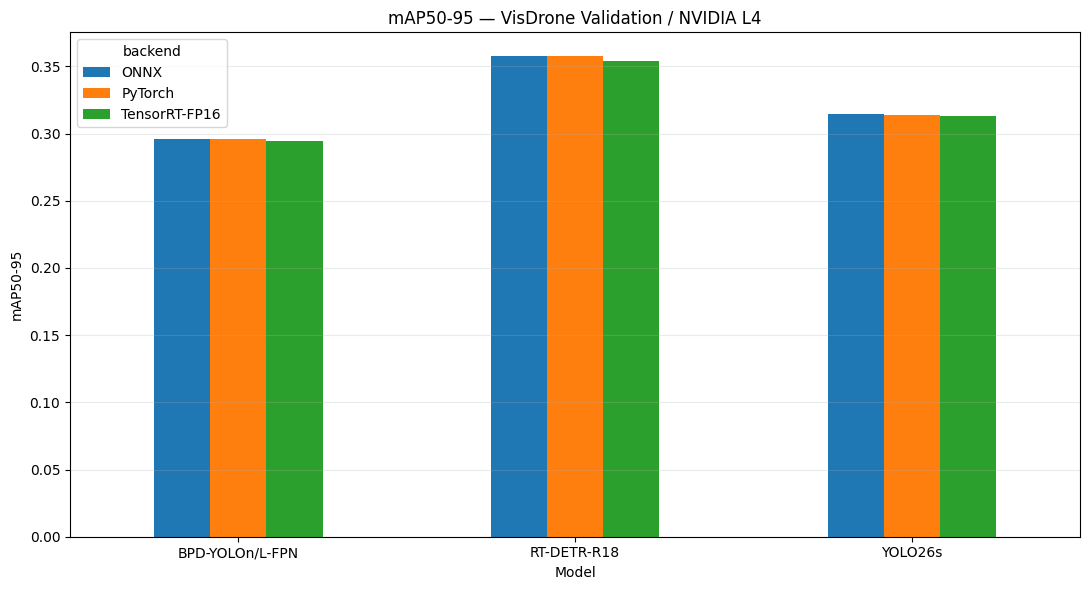

Saved: /content/drive/MyDrive/aerial_human_detection/step4_final/06_REPORT_ASSETS/accuracy_map50_95.png


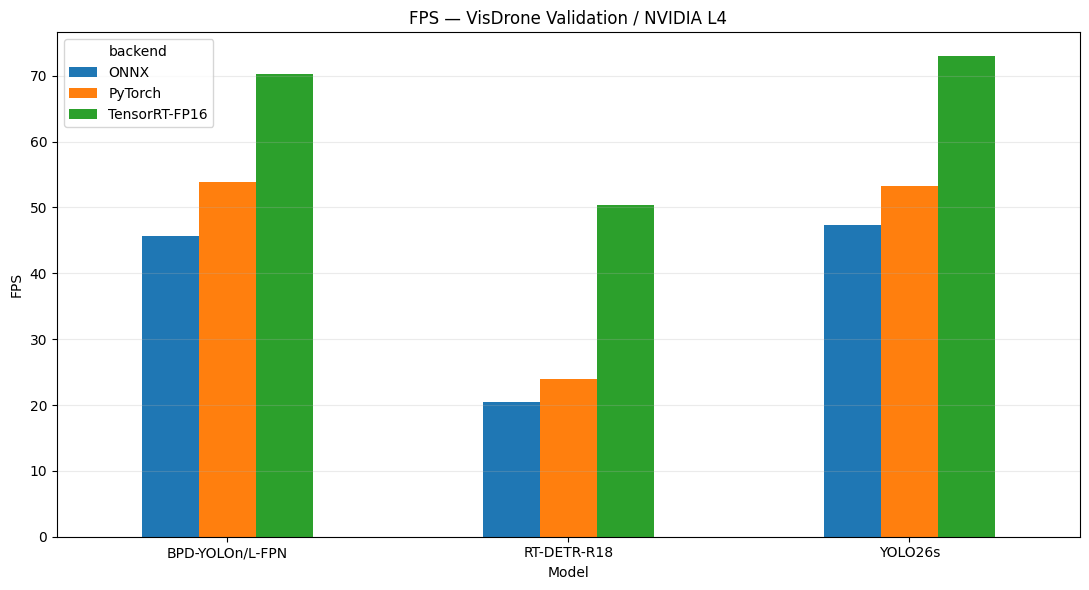

Saved: /content/drive/MyDrive/aerial_human_detection/step4_final/06_REPORT_ASSETS/fps_comparison.png


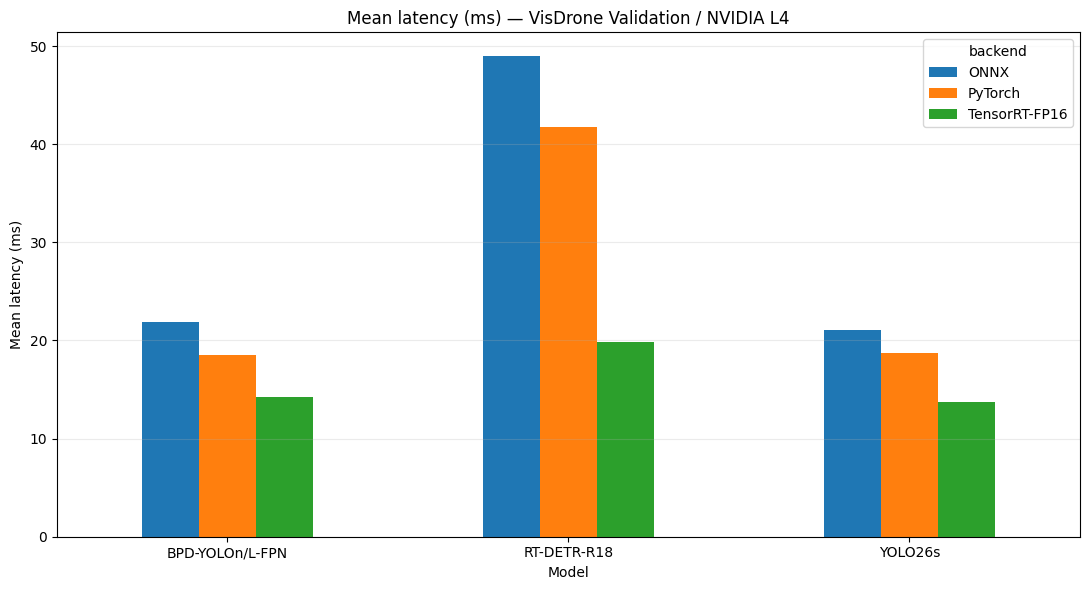

Saved: /content/drive/MyDrive/aerial_human_detection/step4_final/06_REPORT_ASSETS/latency_comparison.png


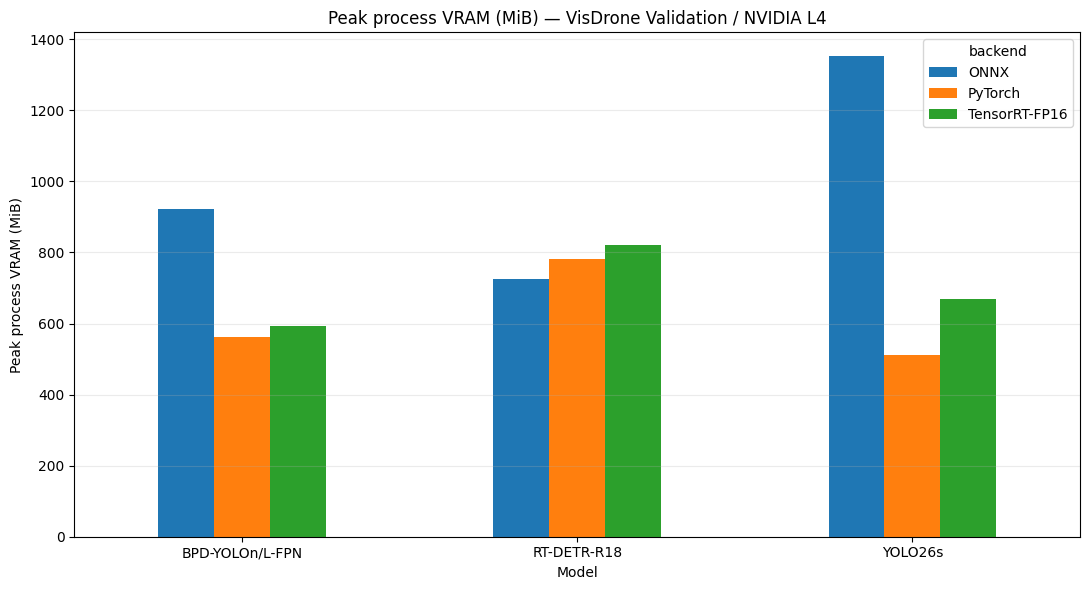

Saved: /content/drive/MyDrive/aerial_human_detection/step4_final/06_REPORT_ASSETS/vram_comparison.png


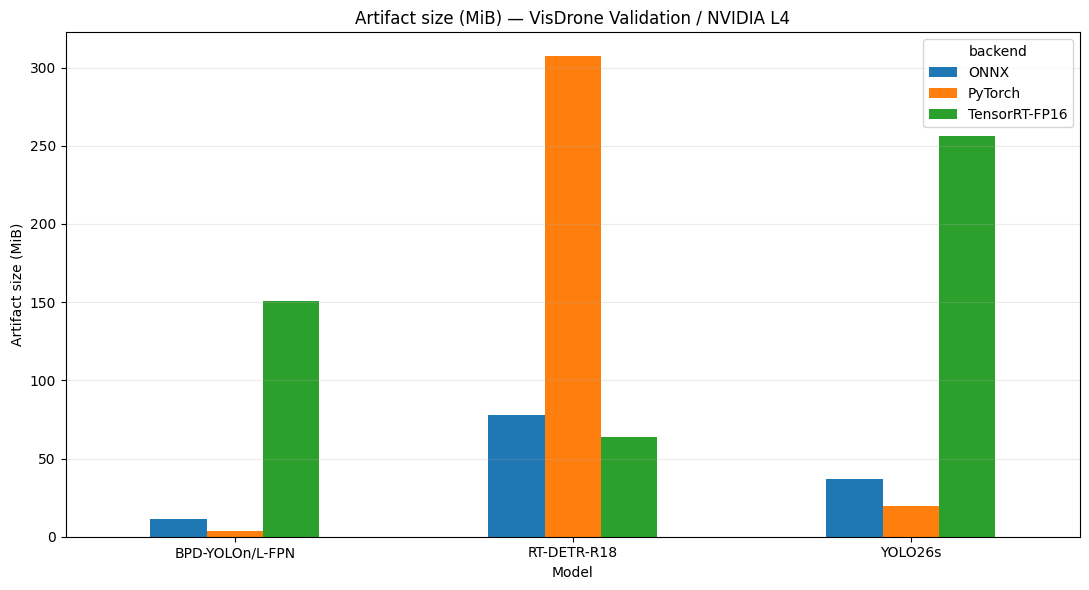

Saved: /content/drive/MyDrive/aerial_human_detection/step4_final/06_REPORT_ASSETS/model_size_comparison.png
Report charts: COMPLETE


In [ ]:
import matplotlib.pyplot as plt


def plot_metric(metric, ylabel, filename):
    pivot = results_df.pivot(
        index="model",
        columns="backend",
        values=metric,
    )

    ax = pivot.plot(
        kind="bar",
        figsize=(11, 6),
    )

    ax.set_xlabel("Model")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel + " — VisDrone Validation / NVIDIA L4")
    ax.grid(axis="y", alpha=0.25)

    plt.xticks(rotation=0)
    plt.tight_layout()

    output_path = REPORT_ASSETS_DIR / filename
    plt.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", output_path)


plot_metric(
    "map50_95",
    "mAP50-95",
    "accuracy_map50_95.png",
)

plot_metric(
    "fps",
    "FPS",
    "fps_comparison.png",
)

plot_metric(
    "mean_latency_ms",
    "Mean latency (ms)",
    "latency_comparison.png",
)

plot_metric(
    "peak_vram_mb",
    "Peak process VRAM (MiB)",
    "vram_comparison.png",
)

plot_metric(
    "artifact_size_mb",
    "Artifact size (MiB)",
    "model_size_comparison.png",
)

print("Report charts: COMPLETE")

## 18. Final integrity manifest and delivery summary

In [ ]:
manifest_models = {}

for model_name in [
    "YOLO26s",
    "RT-DETR-R18",
    "BPD-YOLOn/L-FPN",
]:
    artifacts = {}

    for key, value in MODEL_ARTIFACTS[model_name].items():
        if isinstance(value, Path):
            artifacts[key] = str(value)
        else:
            artifacts[key] = value

    manifest_models[model_name] = artifacts


manifest = {
    "project_step": 4,
    "title": "Inference optimization and deployment backend benchmarking",
    "created_at": datetime.now().isoformat(),
    "hardware": {
        "benchmark_gpu": GPU_NAME,
        "benchmark_gpu_tag": GPU_TAG,
        "target_hardware_from_project": "RTX 3070",
        "rtx3070_benchmark_completed": False,
        "note": (
            "TensorRT engines in this delivery were built on the active benchmark GPU. "
            "Rebuild TensorRT engines on the final RTX 3070 system when available."
        ),
    },
    "dataset": {
        "name": "VisDrone2019-DET",
        "split": "validation",
        "images": len(VAL_IMAGE_FILES),
        "target_class": "person",
        "native_mapping": {
            "1": "pedestrian -> person",
            "2": "people -> person",
        },
        "archive": str(VAL_ARCHIVE),
        "archive_bytes": VAL_ARCHIVE.stat().st_size,
        "archive_sha256": sha256_file(VAL_ARCHIVE),
        "ground_truth_coco": str(COCO_GT_JSON),
        "private_final_test_used": False,
    },
    "configuration": execution_config,
    "environment": environment,
    "models": manifest_models,
    "comparison_files": {
        "full_results_csv": str(FULL_RESULTS_CSV),
        "full_results_json": str(FULL_RESULTS_JSON),
        "report_assets": str(REPORT_ASSETS_DIR),
    },
    "export_errors": EXPORT_ERRORS,
    "benchmark_errors": BENCHMARK_ERRORS,
}

MANIFEST_PATH = OUTPUT_ROOT / "step4_manifest.json"

MANIFEST_PATH.write_text(
    json.dumps(
        manifest,
        indent=2,
    ),
    encoding="utf-8",
)

print("\n" + "=" * 96)
print("STEP 4 FINAL DELIVERY")
print("=" * 96)
print("Output root :", OUTPUT_ROOT)
print("Manifest    :", MANIFEST_PATH)
print("Results CSV :", FULL_RESULTS_CSV)
print("Results JSON:", FULL_RESULTS_JSON)
print("Charts      :", REPORT_ASSETS_DIR)
print("GPU         :", GPU_NAME)
print("=" * 96)

for model_name in [
    "YOLO26s",
    "RT-DETR-R18",
    "BPD-YOLOn/L-FPN",
]:
    print("\n" + model_name)

    model_rows = results_df[
        results_df["model"] == model_name
    ].copy()

    if model_rows.empty:
        print("  No successful benchmark rows.")
        continue

    for _, row in model_rows.iterrows():
        print(
            f"  {row['backend']:16s} | "
            f"mAP50-95={row['map50_95']:.5f} | "
            f"AP50={row['ap50']:.5f} | "
            f"FPS={row['fps']:.2f} | "
            f"P95={row['p95_latency_ms']:.2f} ms"
        )

print("\nSTEP 4 PIPELINE: COMPLETE")


STEP 4 FINAL DELIVERY
Output root : /content/drive/MyDrive/aerial_human_detection/step4_final
Manifest    : /content/drive/MyDrive/aerial_human_detection/step4_final/step4_manifest.json
Results CSV : /content/drive/MyDrive/aerial_human_detection/step4_final/04_COMPARISON/full_step4_results.csv
Results JSON: /content/drive/MyDrive/aerial_human_detection/step4_final/04_COMPARISON/full_step4_results.json
Charts      : /content/drive/MyDrive/aerial_human_detection/step4_final/06_REPORT_ASSETS
GPU         : NVIDIA L4

YOLO26s
  PyTorch          | mAP50-95=0.31377 | AP50=0.67895 | FPS=53.32 | P95=19.82 ms
  ONNX             | mAP50-95=0.31420 | AP50=0.67974 | FPS=47.36 | P95=21.65 ms
  TensorRT-FP16    | mAP50-95=0.31294 | AP50=0.67959 | FPS=72.94 | P95=14.51 ms

RT-DETR-R18
  PyTorch          | mAP50-95=0.35738 | AP50=0.72953 | FPS=23.98 | P95=42.62 ms
  ONNX             | mAP50-95=0.35744 | AP50=0.72955 | FPS=20.43 | P95=49.98 ms
  TensorRT-FP16    | mAP50-95=0.35367 | AP50=0.72630 | FPS=

In [2]:
# ============================================================
# CREATE STEP-4 REPORT BUNDLE
# Excludes heavy model artifacts and keeps report evidence only.
# ============================================================

from pathlib import Path
import shutil
import os

STEP4_ROOT = Path(
    "/content/drive/MyDrive/aerial_human_detection/step4_final"
)

BUNDLE_ROOT = Path(
    "/content/step4_report_bundle"
)

ZIP_OUTPUT = Path(
    "/content/drive/MyDrive/aerial_human_detection/step4_report_bundle"
)

if BUNDLE_ROOT.exists():
    shutil.rmtree(BUNDLE_ROOT)

BUNDLE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

# File types useful for the technical report.
KEEP_EXTENSIONS = {
    ".csv",
    ".json",
    ".txt",
    ".yaml",
    ".yml",
    ".png",
    ".jpg",
    ".jpeg",
    ".svg",
    ".md",
    ".log",
    ".ipynb",
}

# Heavy deployment/model artifacts are intentionally excluded.
EXCLUDE_EXTENSIONS = {
    ".engine",
    ".onnx",
    ".pt",
    ".pth",
    ".zip",
    ".tar",
    ".gz",
}

copied_files = []

for source in STEP4_ROOT.rglob("*"):

    if not source.is_file():
        continue

    suffix = source.suffix.lower()

    if suffix in EXCLUDE_EXTENSIONS:
        continue

    if suffix not in KEEP_EXTENSIONS:
        continue

    relative_path = source.relative_to(
        STEP4_ROOT
    )

    destination = (
        BUNDLE_ROOT
        / "step4_final"
        / relative_path
    )

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    shutil.copy2(
        source,
        destination,
    )

    copied_files.append(
        relative_path
    )


# ------------------------------------------------------------
# Try to include the executed Step-4 notebook if it exists
# outside the output directory.
# ------------------------------------------------------------

possible_notebooks = [
    Path(
        "/content/Step4_Final_Deployment_Optimization_3Models_VisDrone_L4.ipynb"
    ),
    Path(
        "/content/drive/MyDrive/"
        "Step4_Final_Deployment_Optimization_3Models_VisDrone_L4.ipynb"
    ),
    Path(
        "/content/drive/MyDrive/aerial_human_detection/"
        "Step4_Final_Deployment_Optimization_3Models_VisDrone_L4.ipynb"
    ),
]

for notebook in possible_notebooks:

    if notebook.exists():

        shutil.copy2(
            notebook,
            BUNDLE_ROOT / notebook.name,
        )

        print(
            "Notebook included:",
            notebook,
        )

        break


# ------------------------------------------------------------
# Save bundle inventory.
# ------------------------------------------------------------

inventory_file = (
    BUNDLE_ROOT
    / "REPORT_BUNDLE_INVENTORY.txt"
)

with inventory_file.open(
    "w",
    encoding="utf-8",
) as stream:

    for item in sorted(
        copied_files,
        key=lambda x: str(x).lower(),
    ):
        stream.write(
            str(item) + "\n"
        )


# ------------------------------------------------------------
# Create ZIP.
# ------------------------------------------------------------

zip_path = shutil.make_archive(
    str(ZIP_OUTPUT),
    "zip",
    root_dir=BUNDLE_ROOT,
)

size_mb = (
    Path(zip_path).stat().st_size
    / 1024
    / 1024
)

print("=" * 100)
print("STEP-4 REPORT BUNDLE: READY")
print("=" * 100)
print("Files included :", len(copied_files))
print("ZIP path       :", zip_path)
print("ZIP size MB    :", f"{size_mb:.2f}")

STEP-4 REPORT BUNDLE: READY
Files included : 60
ZIP path       : /content/drive/MyDrive/aerial_human_detection/step4_report_bundle.zip
ZIP size MB    : 65.92


## 19. Delivery checklist

A complete successful run should leave these artifacts in Google Drive:

```text
step4_final/
├── 00_DATA/
│   ├── VisDrone2019-DET-val.zip
│   ├── visdrone_val_person_only_coco.json
│   └── visdrone_val_image_index.json
├── 01_YOLO26s/
│   ├── 01_checkpoint/
│   ├── 02_onnx/
│   ├── 03_tensorrt_fp16/
│   └── 04_benchmark/
├── 02_RTDETR_R18/
│   ├── 01_checkpoint/
│   ├── 02_onnx/
│   ├── 03_tensorrt_fp16/
│   └── 04_benchmark/
├── 03_BPD_YOLOn_LFPN/
│   ├── 01_checkpoint/
│   ├── 02_onnx/
│   ├── 03_tensorrt_fp16/
│   └── 04_benchmark/
├── 04_COMPARISON/
├── 05_ENVIRONMENT/
├── 06_REPORT_ASSETS/
└── step4_manifest.json
```

### Interpretation
- **PyTorch** is the reference checkpoint backend.
- **ONNX** is the portable deployment artifact.
- **TensorRT FP16** is the GPU-optimized artifact built for the active NVIDIA GPU.
- Accuracy deltas should be interpreted against the PyTorch baseline.
- L4 speed measurements must be reported as **NVIDIA L4 benchmark results**, not RTX 3070 results.
- The private Final Test remains untouched for the later independent final evaluation.